In [1]:
%load_ext autoreload 
#hopefully this will`` reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

In [2]:
%system free -m

['               total        used        free      shared  buff/cache   available',
 'Mem:          257185       11435      119953          24      127636      245750',
 'Swap:          19999          14       19985']

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [3]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
from myproject.listRedshiftGalaxys import ListRedshiftGalaxy
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.compilingPlottinFunctions import asymetryPlots, getConsistentInconsistentPolarMRLPlots, getConsistentInconsistentAssymetryPlots

from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, NullLocator, MultipleLocator


In [4]:
allSnapshotEnums = SnapshotEnum.getAllSnapshots()
# allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]

#get rid of snapshots < 50:
allSnapshotEnums = [snapshotEnum for snapshotEnum in allSnapshotEnums if snapshotEnum[0] >= 50]
allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]
print(allSnapshots)

[99, 91, 84, 78, 72, 67, 59, 50]


In [5]:
mass_bin_labels = [
    '$1e13<M_{200c}<1e13.5$',
    '$1e13.5<M_{200c}<1e14$',
    '$1e14<M_{200c}<1e14.5$',
    '$1e14.5<M_{200c}<1e15$',
    '$M_{200c}>1e15$',
]

In [6]:
#mass bin colors to keep consistent across all plots
mass_bin_colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
]

In [7]:
listRedshiftGalaxyAnalysis = ListRedshiftGalaxy()
listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG300-1, TNG-Cluster', luminosityType='Default', generalErrorbar='poisson', generalRewrite=True)
# listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG300-1', luminosityType='Default', generalErrorbar='poisson', generalRewrite=True)
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True)

Progress: 3732/3732
Loaded 3732 galaxy groups from HDF5.
Progress: 352/352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
Progress: 3707/3707g Galaxy Group ID 4084 / 4084
Loaded 3707 galaxy groups from HDF5.
Progress: 352/352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
Progress: 3643/3643g Galaxy Group ID 4059 / 4059
Loaded 3643 galaxy groups from HDF5.
Progress: 352/352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
Progress: 3557/3557g Galaxy Group ID 3995 / 3995
Loaded 3557 galaxy groups from HDF5.
Progress: 360/360
Loaded 360 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
Progress: 3388/3388g Galaxy Group ID 3917 / 3917
Loaded 3388 galaxy groups fr

In [8]:
# Based on snapshot 99, trace each halo back with merger trees (MPB) and keep mass bins static.

# from typing import Iterable

# import illustris_python as il

# # Get the MPB for the central subhalo
# tree = il.sublink.loadTree(basePath, snap, subhaloID,
#                            fields=['SnapNum', 'SubfindID', 'SubhaloGrNr'],
#                            onlyMPB=True)

# tree['SubfindID'][i] is the subhalo ID at tree['SnapNum'][i]

# Based on snapshot 99, trace each halo back with merger trees (MPB)
# and keep mass bins static with respect to snapshot 99.

# Based on snapshot 99, trace each halo back with merger trees (MPB)
# and keep mass bins static with respect to snapshot 99.

from typing import Iterable
import os

import illustris_python as il

try:
    import h5py
except ImportError:  # optional (only needed if you load per-halo MPB files)
    h5py = None


def _try_load_mpb_file(
    *,
    basePath: str,
    central_subfind_id0: int,
    fields: list[str],
) -> dict[str, "object"] | None:
    """Attempt to load a per-halo MPB file like sublink_mpb_<id>.hdf5.

    Returns a dict of arrays if found, else None.
    """
    fname = f"sublink_mpb_{int(central_subfind_id0)}.hdf5"
    candidates = [
        os.path.join(basePath, fname),
        os.path.join(basePath, "mergerTree", fname),
    ]

    mpb_path = next((p for p in candidates if os.path.exists(p)), None)
    if mpb_path is None:
        return None

    if h5py is None:
        raise ImportError(
            "Found per-halo MPB file but h5py is not installed in this environment."
        )

    with h5py.File(mpb_path, "r") as f:
        g = f["Tree"] if "Tree" in f else f
        out: dict[str, object] = {}
        for field in fields:
            if field in g:
                out[field] = g[field][...]
            elif field in f:
                out[field] = f[field][...]
            else:
                raise KeyError(
                    f"Field '{field}' not found in {mpb_path}. Available: {list(g.keys())}"
                )
        return out


def trace_central_mpb_group_numbers(
    *,
    basePath: str,
    snap0: int,
    central_subfind_id0: int,
    target_snaps: Iterable[int],
) -> dict[int, int]:
    """Map snapshot -> FoF group number (SubhaloGrNr) along the central's MPB.

    Supports two layouts:
    1) illustris_python standard basePath containing postprocessing/offsets (uses il.sublink.loadTree)
    2) a directory containing per-halo files like sublink_mpb_<SubfindID>.hdf5 (loaded via h5py)
    """
    if not basePath:
        raise ValueError("basePath is empty")

    fields = ["SnapNum", "SubfindID", "SubhaloGrNr"]

    tree = _try_load_mpb_file(
        basePath=basePath,
        central_subfind_id0=int(central_subfind_id0),
        fields=fields,
    )

    if tree is None:
        tree = il.sublink.loadTree(
            basePath,
            int(snap0),
            int(central_subfind_id0),
            fields=fields,
            onlyMPB=True,
        )

    snap_to_group: dict[int, int] = {}
    for snap, grnr in zip(tree["SnapNum"], tree["SubhaloGrNr"]):
        s = int(snap)
        if s not in snap_to_group:
            snap_to_group[s] = int(grnr)

    return {int(s): snap_to_group[int(s)] for s in target_snaps if int(s) in snap_to_group}



In [9]:
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.listRedshiftGalaxys import ListRedshiftGalaxy

import numpy as np

# We keep using the combined analysis object (created earlier) for downstream plots,
# but we build the static-mass-bin membership by tracing halos separately in each sim.

# Use snapshot 99 as the reference for static mass bins
snap0 = 99

# basePath for tracing can be either:
#  - a standard illustris_python basePath (contains postprocessing/offsets + trees), OR
#  - a directory with per-halo MPB files named sublink_mpb_<SubfindID>.hdf5

sims_to_trace = ["TNG300-1", "TNG-Cluster"]
# sims_to_trace = ["TNG300-1"]
base_paths = {
    "TNG300-1": "/scratch/poulin.al/lopsided/TNG300-1/z0p0/data/mergerTree",
    "TNG-Cluster": "/scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/mergerTree",
}


# Validate base paths
missing = [sim for sim in sims_to_trace if not base_paths.get(sim)]
if missing:
    raise ValueError(
        "Missing base path(s) for: "
        + ", ".join(missing)
        + ". Set base_paths[...] to your tree data location."
    )

for sim in sims_to_trace:
    bp = str(base_paths[sim])
    if not os.path.isdir(bp):
        raise FileNotFoundError(f"basePath does not exist or is not a directory: {bp}")

# Initialize per-simulation loaders (so we can unambiguously fetch the traced FoF group at each snapshot)
listRedshift_by_sim: dict[str, ListRedshiftGalaxy] = {}
# for sim in sims_to_trace:
#     lrg = ListRedshiftGalaxy()
#     lrg.initializeAllGalaxyAnalysis(
#         snapshot_enums=allSnapshots,
#         simulation=sim,
#         luminosityType="Default",
#         generalErrorbar="poisson",
#         generalRewrite=True,
#     )
#     listRedshift_by_sim[sim] = lrg

# Initialize TNG300-1 and TNG-Cluster separately so tracing works correctly
for sim in sims_to_trace:
    lrg = ListRedshiftGalaxy()
    lrg.initializeAllGalaxyAnalysis(
        snapshot_enums=allSnapshots,
        simulation=sim,
        luminosityType="Default",
        generalErrorbar="poisson",
        generalRewrite=False,  # Set to False if data is already cached
    )
    listRedshift_by_sim[sim] = lrg
    
# Collect z=0 reference halos, grouped by mass bin, for each simulation.
# Each reference halo is represented by the central subfind ID at snap0.
refs_by_sim_by_bin: dict[str, list[list[tuple[int, int]]]] = {}  # sim -> bin -> [(centralSubfindID, z0GroupID), ...]

for sim in sims_to_trace:
    ga0 = listRedshift_by_sim[sim].getGalaxyAnalysisSnapshot(snap0)

    z0_bins = [
        ga0.filtered_gt13_ls13p5_list_of_galaxy_groups,
        ga0.filtered_gt13p5_ls14_list_of_galaxy_groups,
        ga0.filtered_gt14_ls14p5_list_of_galaxy_groups,
        ga0.filtered_gt14p5_ls15_list_of_galaxy_groups,
        ga0.filtered_gt15_list_of_galaxy_groups,
    ]

    sim_refs: list[list[tuple[int, int]]] = [[] for _ in range(len(z0_bins))]
    for bin_i, lgg in enumerate(z0_bins):
        for gg in lgg.getAllGalaxyGroups():
            central_id0 = int(gg.getCentralSubhalo().getIdx())
            sim_refs[bin_i].append((central_id0, int(gg.getGroupID())))

    refs_by_sim_by_bin[sim] = sim_refs
    print(
        f"{sim} z=0 (snap 99) ref counts by bin:",
        [len(x) for x in sim_refs],
    )

# Build trace maps: (sim, centralSubfindID@99) -> {snap -> groupNumber@snapi}
# NOTE: this can be slow if you have many halos.
trace_map: dict[str, dict[int, dict[int, int]]] = {sim: {} for sim in sims_to_trace}

for sim in sims_to_trace:
    bp = base_paths[sim]
    all_refs = [cid for bin_refs in refs_by_sim_by_bin[sim] for (cid, _) in bin_refs]

    for k, central_id0 in enumerate(all_refs, start=1):
        if central_id0 in trace_map[sim]:
            continue
        if k % 50 == 0 or k == len(all_refs):
            print(f"Tracing {sim}: {k}/{len(all_refs)}")
        trace_map[sim][central_id0] = trace_central_mpb_group_numbers(
            basePath=bp,
            snap0=snap0,
            central_subfind_id0=central_id0,
            target_snaps=allSnapshots,
        )

# Finally, for each snapshot, build static mass bins by *tracing* each z=0 halo to its FoF group number
# and fetching that group from the per-sim catalogs, then combine both sims into the bin.
combined_lgg_by_snap: dict[int, list[ListGalaxyGroup]] = {}
for snap in allSnapshots:
    mass_bins_groups: list[list] = [[] for _ in range(5)]  # each entry becomes a ListGalaxyGroup

    for sim in sims_to_trace:
        ga_snap = listRedshift_by_sim[sim].getGalaxyAnalysisSnapshot(snap)

        for bin_i, bin_refs in enumerate(refs_by_sim_by_bin[sim]):
            for central_id0, _z0_gid in bin_refs:
                gnum = trace_map[sim][central_id0].get(int(snap))
                if gnum is None:
                    continue
                gg = ga_snap.loaded_list_of_galaxy_groups.getGalaxyGroupByID(int(gnum))
                if gg is None:
                    continue
                mass_bins_groups[bin_i].append(gg)

    # Wrap as ListGalaxyGroup and set on the combined analysis object used later in the notebook
    mass_bins_lgg = [ListGalaxyGroup(bin_list) for bin_list in mass_bins_groups]
    combined_lgg_by_snap[int(snap)] = mass_bins_lgg

    ga_combined = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snap)
    ga_combined.setMassSubgroups(mass_bins_lgg)
    print(f"Access later with listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot({snap}).filtered_gt13_ls13p5_list_of_galaxy_groups, etc.")

    print(
        f"snap {snap}: traced static bins have",
        [len(lgg.getAllGalaxyGroups()) for lgg in mass_bins_lgg],
        "groups",
    )


Progress: 3732/3732
Loaded 3732 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
Progress: 3707/3707g Galaxy Group ID 3732 / 3732
Loaded 3707 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
Progress: 3643/3643g Galaxy Group ID 3707 / 3707
Loaded 3643 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
Progress: 3557/3557g Galaxy Group ID 3643 / 3643
Loaded 3557 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
Progress: 3388/3388g Galaxy Group ID 3557 / 3557
Loaded 3388 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p4/data/galaxy_data_TNG300-1_.hdf5
Progress: 3243/3243g Galaxy Group ID 3388 / 3388
Loaded 3243 galaxy groups from HDF5.
Loaded galaxy data from

In [10]:
def getTracedMassBinsForSnap(snap: int) -> list[ListGalaxyGroup]:
    """Fetch traced mass bins for one snapshot (combined across TNG300-1 and TNG-Cluster)."""
    return combined_lgg_by_snap.get(int(snap), [ListGalaxyGroup([]) for _ in range(5)])


def getAllTracedGroupsForSnap(snap: int) -> ListGalaxyGroup:
    """Fetch one flattened ListGalaxyGroup for a snapshot from traced bins."""
    bins = getTracedMassBinsForSnap(snap)
    all_groups = [gg for mass_bin in bins for gg in mass_bin.getAllGalaxyGroups()]
    return ListGalaxyGroup(all_groups)


def buildCombinedListRedshiftGalaxyAnalysisFromTracedBins() -> ListRedshiftGalaxy:
    """Build one ListRedshiftGalaxy containing the traced+combined LGG for all snapshots."""
    combined = ListRedshiftGalaxy()

    for snap in allSnapshots:
        snap_i = int(snap)
        ga = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snap_i)

        mass_bins = getTracedMassBinsForSnap(snap_i)
        print(f"len each mass bin for snap {snap_i}:", [len(bin.getAllGalaxyGroups()) for bin in mass_bins])
        merged_lgg = getAllTracedGroupsForSnap(snap_i)

        # Keep both representations synchronized on the same snapshot object.
        ga.loaded_list_of_galaxy_groups = merged_lgg
        ga.setMassSubgroups(mass_bins)
        print(f"len of ga each mass bin for snap {snap_i}:", [len(bin.getAllGalaxyGroups()) for bin in mass_bins])


        combined.addGalaxyAnalysis(snap_i, ga)

    return combined


def getListRedshiftGalaxyAnalysisForSnap(snap: int) -> GalaxyAnalysis:
    """Convenience accessor from the combined traced object."""
    return listRedshiftGalaxyAnalysisCombined.getGalaxyAnalysisSnapshot(int(snap))
    # return listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(int(snap))


# Single combined object you can use everywhere downstream.
listRedshiftGalaxyAnalysisCombined = buildCombinedListRedshiftGalaxyAnalysisFromTracedBins()
print(
    "Built combined traced ListRedshiftGalaxy for snapshots:",
    listRedshiftGalaxyAnalysisCombined.getAllLoadedSnapshots(),
)
print(f"len of combined analysis for each mass bin for each snap:", {
    snap: [len(bin.getAllGalaxyGroups()) for bin in getTracedMassBinsForSnap(snap)]
    for snap in allSnapshots
})


snapshot99_ga = getListRedshiftGalaxyAnalysisForSnap(99)
print(f"len of snapshot 99 combined analysis for each mass bin:", [len(bin.getAllGalaxyGroups()) for bin in getTracedMassBinsForSnap(99)])

snapshot91_ga = getListRedshiftGalaxyAnalysisForSnap(91)
print(f"len of snapshot 91 combined analysis for each mass bin:", [len(bin.getAllGalaxyGroups()) for bin in getTracedMassBinsForSnap(91)])

len each mass bin for snap 99: [2586, 866, 292, 242, 98]
len of ga each mass bin for snap 99: [2586, 866, 292, 242, 98]
len each mass bin for snap 91: [2317, 865, 291, 240, 98]
len of ga each mass bin for snap 91: [2317, 865, 291, 240, 98]
len each mass bin for snap 84: [2105, 864, 290, 242, 98]
len of ga each mass bin for snap 84: [2105, 864, 290, 242, 98]
len each mass bin for snap 78: [1933, 862, 288, 242, 97]
len of ga each mass bin for snap 78: [1933, 862, 288, 242, 97]
len each mass bin for snap 72: [1729, 854, 288, 242, 98]
len of ga each mass bin for snap 72: [1729, 854, 288, 242, 98]
len each mass bin for snap 67: [1531, 850, 287, 242, 98]
len of ga each mass bin for snap 67: [1531, 850, 287, 242, 98]
len each mass bin for snap 59: [1155, 826, 286, 242, 98]
len of ga each mass bin for snap 59: [1155, 826, 286, 242, 98]
len each mass bin for snap 50: [675, 749, 284, 241, 97]
len of ga each mass bin for snap 50: [675, 749, 284, 241, 97]
Built combined traced ListRedshiftGalaxy f

In [16]:
#for snapshot 99, check how many subhalos have non nan joining redshifts compared to nan joining redshifts:
galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
# loaded_list_of_galaxy = galaxyAnalysis.loaded_list_of_galaxy_groups
loaded_list_of_galaxy = galaxyAnalysis.filtered_gt14_list_of_galaxy_groups
num_subhalos = np.sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in loaded_list_of_galaxy.getAllGalaxyGroups()])
num_subhalos_nan_joining_redshifts = 0
num_subhalos_non_nan_joining_redshifts = 0
for galaxy_group in loaded_list_of_galaxy.getAllGalaxyGroups():
    for satellite_subhalo in galaxy_group.getSatelliteSubhalos():
        if np.isnan(satellite_subhalo.getJoiningRedshift()):
            num_subhalos_nan_joining_redshifts += 1
            # print(satellite_subhalo.getJoiningRedshift())
        else:
            num_subhalos_non_nan_joining_redshifts += 1
print(f"Snapshot 99: Num subhalos: {num_subhalos}, Num subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts}, Num subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts}")
print(f"Snapshot 99: Fraction of subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts/num_subhalos}, Fraction of subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts/num_subhalos}")

Snapshot 99: Num subhalos: 123356, Num subhalos with nan joining redshifts: 2161, Num subhalos with non-nan joining redshifts: 121195
Snapshot 99: Fraction of subhalos with nan joining redshifts: 0.017518402023411914, Fraction of subhalos with non-nan joining redshifts: 0.9824815979765881


# check snaphot compared to z=0

In [3]:
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')


Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [16]:
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(snapshot[0])
    # redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])
    galaxyAnalysisSnapshot.computeAllPlots()

In [ ]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
# print(f"Number of subhalos in GG 912: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(912).getNumSubhalos()}")
rangeSat, allNumSat = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()
print(f' Range of satellites: {rangeSat}')
print(f' numer of sat == 1: {len(np.where(np.array(allNumSat) < 5)[0])}')

In [17]:
#from galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, save in a txt file
#save all galaxy groups with id, numSat, sum of flags for all satellites, mass, central mass, central flag, central r band, first satellite mass, first satellite flag, first satellite r band
with open('tng_cluster_galaxy_groups_info.txt', 'w') as f:
    f.write('id \t,numSat \t,sumFlags \t,mass \t,centralMass \t,centralFlag \t,centralRband \t,firstSatMass \t,firstSatFlag \t,firstSatRband \n')
    for i in range(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()):
        gg = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(i)
        id = gg.getGroupID()
        numSat = len(gg.getSatelliteSubhalos())
        sumFlags = np.sum([int(subhalo.getFlag()) for subhalo in gg.getSatelliteSubhalos()])
        mass = f'{gg.getMCrit200():.2e}'
        centralMass = f'{gg.getCentralSubhalo().getStellarMass():.2e}'
        centralFlag = gg.getCentralSubhalo().getFlag()
        centralRband = f'{gg.getCentralSubhalo().getDefaultRbandMagnitude():.2}'
        firstSatMass = f'{gg.getSatelliteSubhalos()[0].getStellarMass():.2e}'
        firstSatFlag = gg.getSatelliteSubhalos()[0].getFlag()
        firstSatRband = f'{gg.getSatelliteSubhalos()[0].getDefaultRbandMagnitude():.2}'
        f.write(f'{id} \t,{numSat} \t,{sumFlags} \t,{mass} \t,{centralMass} \t,{centralFlag} \t,{centralRband} \t,{firstSatMass} \t,{firstSatFlag} \t,{firstSatRband} \n')

In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [16]:
galaxyAnalysisZ0.setSnapshot(99, newsim='TNG-Cluster', luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [ ]:

galaxyAnalysisZ0.MRLDistributionPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    if snapshot[0] > 70:
        continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

In [4]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [15]:
print(galaxyAnalysisZ0.sim)

TNG300-1


Processing snapshot 99...
Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 913 with pairs : 18000496
Processing Subhalo 14/14 in Galaxy Group ID 4254241 with total pairs 91103841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 7/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_tng300z0_TNG-Cluster


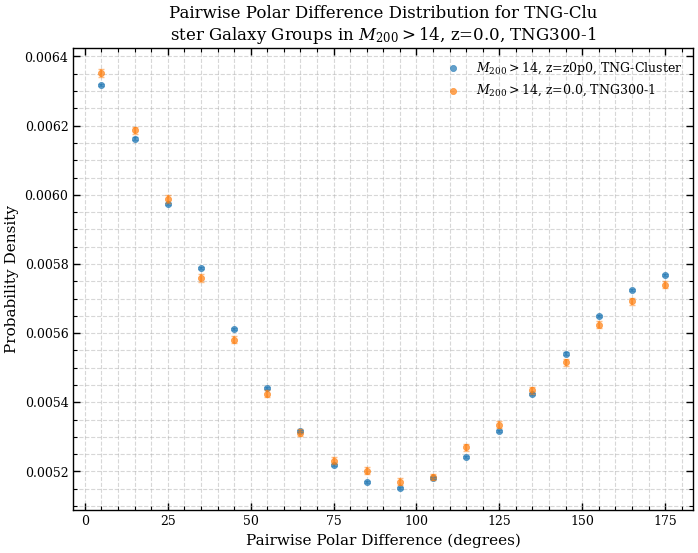

In [18]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] != 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    listRedshiftGG = []
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))
    listRedshiftGG.append(groupList)

    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, mrlOrPolar='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

In [5]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function(list_gg:ListGalaxyGroup, plot_dirc:str='', label=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude()) if label=='SDSS' else rmags.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)
    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

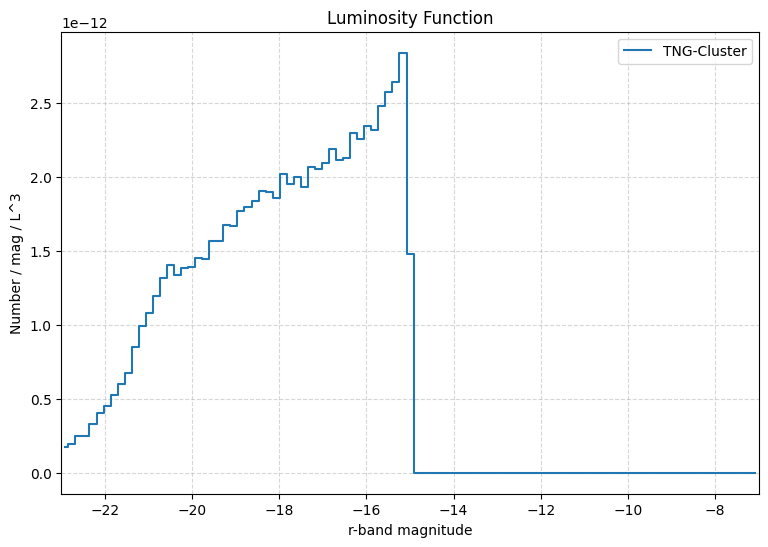

In [7]:
figSDSS, axSDSS = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, ax=axSDSS, label='TNG-Cluster')


In [9]:
%pwd

'/home/poulin.al/git/sat-lopsidedness/src/myproject'

In [10]:
#given a txt file that looks like:
# '''
# # # TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)
# # Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.
# # If you use quantities from this table, please also cite the relevant paper, when indicated for a column.
# # [352] halos, all properties at [z=0] unless specified otherwise.
# #
# # columns: 
# # [1] origID: Original Parent Halo ID (for reference only)
# # [2] haloID: TNG-Cluster Halo ID (in the group catalog)
# # [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]
# # [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]
# # [5] r200c: Halo radius r200c [Mpc]
# #
#    0        0 15.29 15.13 2.629 1.711 12.58 12.76 11.74 10.51 0.145   nan 45.28 -3.69  34.05 -0.79  8.11 0.49 854 502 248  62  CC  0.45  39.57  -0.93  1.69 0.14 0.64 0  0.23  0.67  0.55  0.60  0.45  0.72 
#    1   252455 15.40 15.27 2.871 1.912 12.16 12.49 11.37  9.35 0.126   nan 44.96 -3.48  11.91 -2.16  8.36 0.38 708 423 202  63 NCC 12.96 566.18  -2.20  0.19 0.01 0.12 0  1.91  2.81  1.84  1.35  1.75  1.93 
#    2   476245 15.16 14.99 2.378 1.541 12.16 12.40 11.82 10.17 0.132   nan 44.59 -3.94   3.61 -2.35  8.17 0.39 718 427 210  68 NCC 16.48 515.67  -2.41  0.19 0.01 0.10 0  1.41  2.29  2.23  1.04  1.26  1.63 
#    3   692426 15.36 15.14 2.782 1.731 12.53 12.72 11.55 10.19 0.149   nan 45.06 -3.61   9.16 -1.33  7.95 0.08 628 363 167  49 WCC  1.13  57.04  -1.44  0.81 0.07 0.26 0  1.02  0.46  0.93  2.68  2.72  2.84 
# '''
   
#read the id's
primary_halo_ids = []
with open('tng-cluster-primaryinfo.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
        print(line)
        if line.startswith('#') or line.strip() == '':
            continue  # Skip header or empty lines
        parts = line.split()
        if len(parts) > 1:
            primary_halo_ids.append(int(parts[1]))  # Assuming haloID is the second column
        

# TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)

# Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.

# If you use quantities from this table, please also cite the relevant paper, when indicated for a column.

# [352] halos, all properties at [z=0] unless specified otherwise.

#

# columns: 

# [1] origID: Original Parent Halo ID (for reference only)

# [2] haloID: TNG-Cluster Halo ID (in the group catalog)

# [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]

# [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]

# [5] r200c: Halo radius r200c [Mpc]

# [6] r500c: Halo radius r500c [Mpc]

# [7] mstar_30kpc: Stellar mass within 30 kpc [log(M$_\star$ / M$_\odot$]

# [8] mstar_100kpc: Stellar mass within 100 kpc [log(M$_\star$ / M$_\odot$]

# [9] mhi_halo: Neutral HI mass within the (FoF) halo [log M$_\odot$]

# [10] mass_smbh: Mass of central SMBH [log M$_\odot$]

# [11

In [24]:
galaxyAnalysisZ0PrimaryOnly = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [25]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
#now filter to only the primary halo ids that are in our galaxy groups
filtered_primary_gt14_list_of_galaxy_groups = []
for gg in galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    if gg.getGroupID() in primary_halo_ids:
        print(f"Galaxy group with primary halo ID {gg.getGroupID()} is in the TNG-Cluster catalog.")
        filtered_primary_gt14_list_of_galaxy_groups.append(gg)
        
galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups = ListGalaxyGroup(filtered_primary_gt14_list_of_galaxy_groups, headerInformation=galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getHeaderInformation())        

Galaxy group with primary halo ID 0 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4356618 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4461296 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4561713 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4656216 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4753637 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 476245 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4854863 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4959833 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5059214 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5160063 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5251697 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5348819 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5432141 is in the TNG-Cl

In [28]:
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')


Number of galaxy groups loaded: 352
Number of galaxy groups loaded: 352


COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG-Cluster only primaries
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 6/626 in Galaxy Group ID 0 with total pairs 195625

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_cluster-primaries_TNG-Cluster


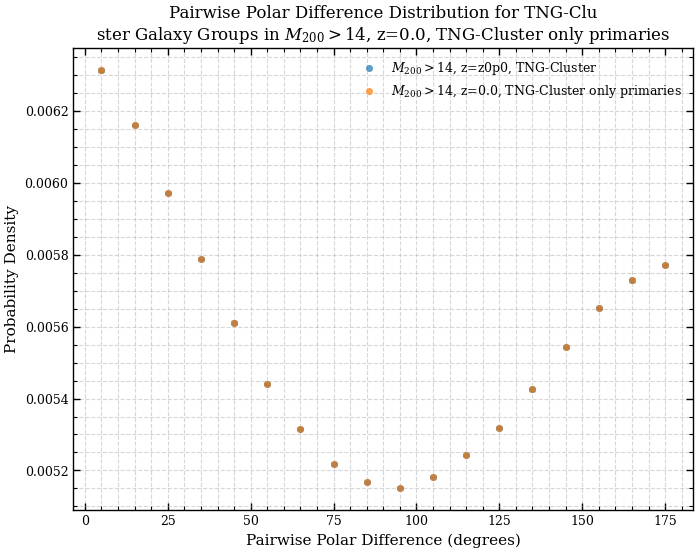

In [27]:
listRedshiftGG = []
# galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
snapshot=(99,)
groupList = []
groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
groupList.append((galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG-Cluster only primaries'))
listRedshiftGG.append(groupList)

polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
# galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
polar_ax.legend(loc='upper right')  # Add legend to the last subplot
polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_cluster-primaries_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

# overall change dependence

## consistency plots

In [12]:
# get the percent of clusters below the 99% / 95% / 90% CL of random MRL, and plot it across redshift
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []
fracBelow99 = []
fracBelow95 = []
fracBelow90 = []

errBelow99 = []
errBelow95 = []
errBelow90 = []


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(snapshot[0])
    redshifts.append(snapshot[1])

    # Note: getPercentOfClustersAboveRandomMRLCL returns the fraction/count/total *below* the percentile.
    (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=99
    )
    (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=95
    )
    (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=90
    )

    fracBelow99.append(f99)
    fracBelow95.append(f95)
    fracBelow90.append(f90)

    errBelow99.append(binomial_sigma(f99, n99))
    errBelow95.append(binomial_sigma(f95, n95))
    errBelow90.append(binomial_sigma(f90, n90))

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.7273 (1379/1896)th 428 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.6176 (1171/1896)th 428 satellites
Fraction of MRL values below the 90th percentile of random MRL values: 0.5353 (1015/1896)th 428 satellites
Processing snapshot 91...
Fraction of MRL values below the 99th percentile of random MRL values: 0.7198 (1300/1806)th 322 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.6019 (1087/1806)th 322 satellites
Fraction of MRL values below the 90th percentile of random MRL values: 0.5299 (957/1806)ith 322 satellites
Processing snapshot 84...
Fraction of MRL values below the 99th percentile of random MRL values: 0.7198 (1246/1731)th 374 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.6060 (1049/1731)th 374 satellites
Fraction of MRL values below the 90th percentile of random MRL val

['/scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_percent_clusters_above_random_MRL_CL_vs_redshift_TNG300-1, TNG-Cluster.pdf',
 '/scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_percent_clusters_above_random_MRL_CL_vs_redshift_TNG300-1, TNG-Cluster.png']

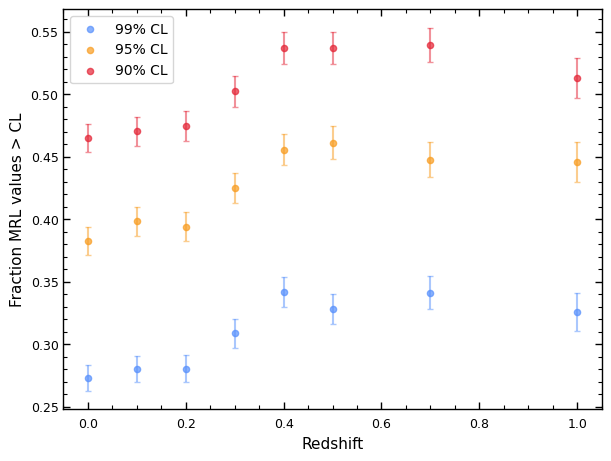

In [13]:
MRL_CL_plotter = AstroPlotter()
MRL_CL_fig, MRL_CL_ax = MRL_CL_plotter.create_figure()

MRL_CL_plotter.scatter_plot(
    redshifts,
    1-np.array(fracBelow99),
    errorBars=errBelow99,
    label='99% CL',
    ax=MRL_CL_ax,
)
MRL_CL_plotter.scatter_plot(
    redshifts,
    1-np.array(fracBelow95),
    errorBars=errBelow95,
    label='95% CL',
    ax=MRL_CL_ax,
)
MRL_CL_plotter.scatter_plot(
    redshifts,
    1-np.array(fracBelow90),
    errorBars=errBelow90,
    label='90% CL',
    ax=MRL_CL_ax,
)

MRL_CL_ax.set_xlabel('Redshift')
MRL_CL_ax.set_ylabel('Fraction MRL values > CL')
# MRL_CL_ax.set_title('Fraction above random MRL CL vs Redshift')
MRL_CL_ax.legend(loc='upper left')

MRL_CL_plotter.save_figure(
    MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/static_percent_clusters_above_random_MRL_CL_vs_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [15]:
# do the same but for the 5 mass groups
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []

mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

fracBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

errBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

countBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
countBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
countBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

totalCount_mass_bins = [[] for _ in range(len(mass_bin_labels))]


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    

    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]

    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])

    for i, mass_bin in enumerate(mass_bins):
        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False, num_samples=10000
        )

        (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=99, random_mrl_values=random_MRL_values
        )
        (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=95, random_mrl_values=random_MRL_values
        )
        (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=90, random_mrl_values=random_MRL_values
        )

        fracBelow99_mass_bins[i].append(f99)
        fracBelow95_mass_bins[i].append(f95)
        fracBelow90_mass_bins[i].append(f90)

        errBelow99_mass_bins[i].append(binomial_sigma(f99, n99))
        errBelow95_mass_bins[i].append(binomial_sigma(f95, n95))
        errBelow90_mass_bins[i].append(binomial_sigma(f90, n90))
        
        countBelow99_mass_bins[i].append(c99)
        countBelow95_mass_bins[i].append(c95)
        countBelow90_mass_bins[i].append(c90)
        
        totalCount_mass_bins[i].append(n99)  # n99, n95, and n90 should all be the same, so just append n99

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.9626 (7468/7758) with 13 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.9037 (7011/7758)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8438 (6546/7758)
Fraction of MRL values below the 99th percentile of random MRL values: 0.9442 (2453/2598)ith 13 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.8772 (2279/2598)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8048 (2091/2598)
Fraction of MRL values below the 99th percentile of random MRL values: 0.8664 (759/876) with 60 satellitess
Fraction of MRL values below the 95th percentile of random MRL values: 0.7614 (667/876)
Fraction of MRL values below the 90th percentile of random MRL values: 0.6884 (603/876)
Fraction of MRL values below the 99th percentile of random MRL values: 0.6722 (488/726) with 317 satellites
Fracti

Created plotter and figs
finished point plotting


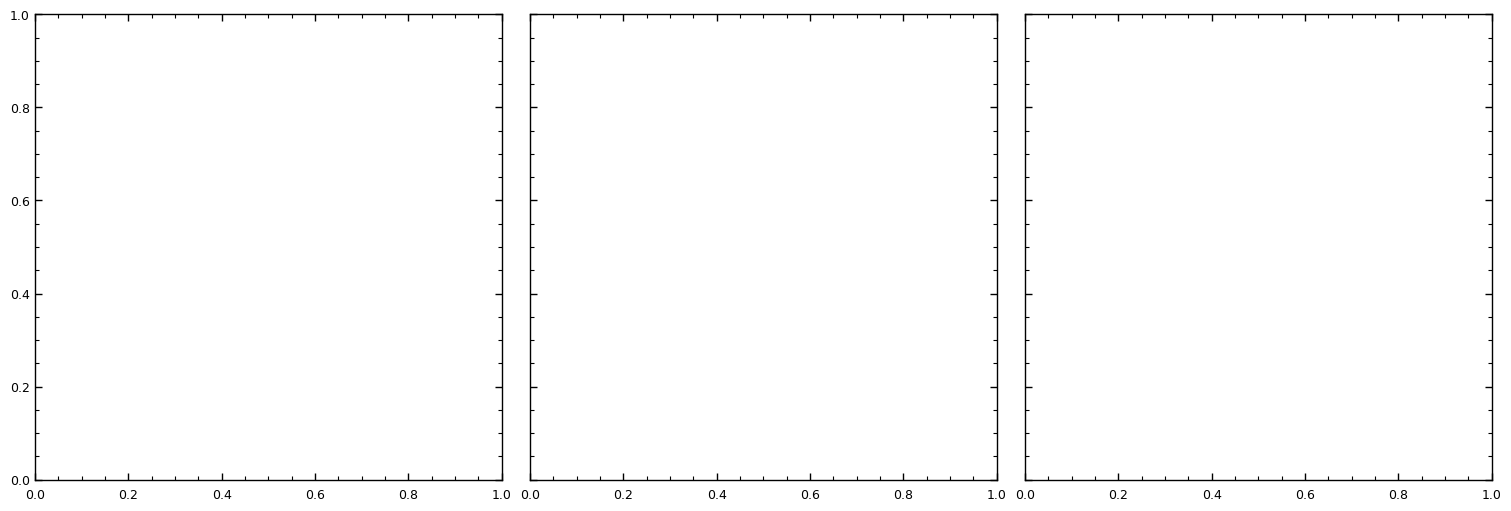

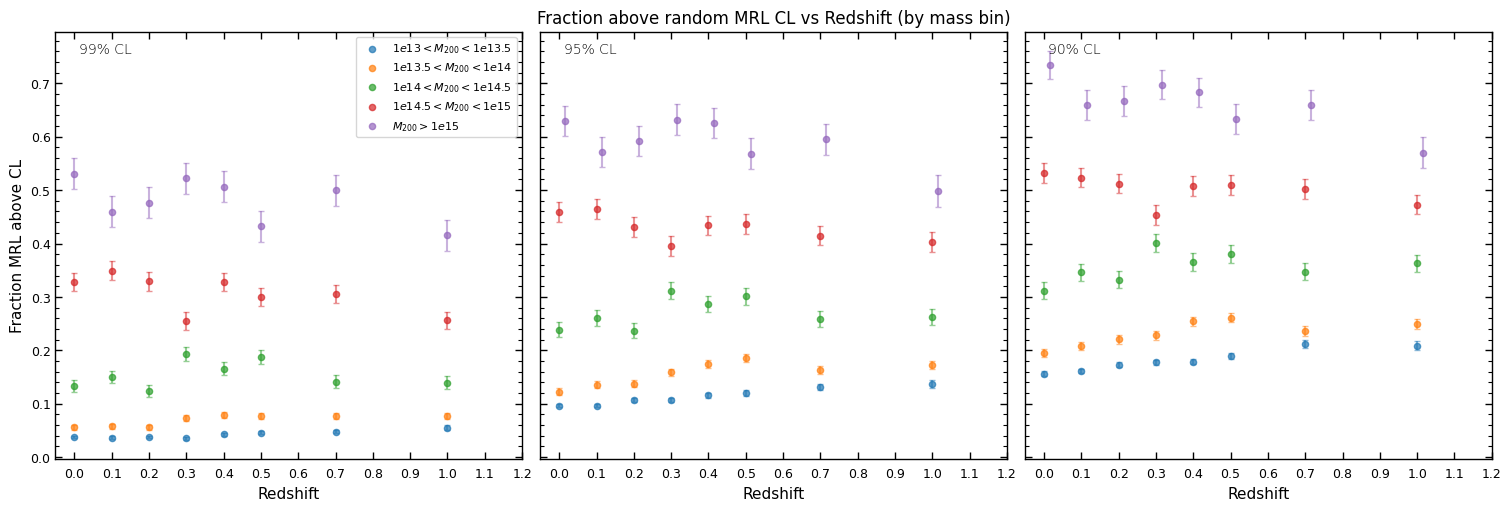

In [16]:
mass_bin_MRL_CL_plotter = AstroPlotter(style='cms', context='paper')
mass_bin_MRL_CL_fig, mass_bin_MRL_CL_ax = mass_bin_MRL_CL_plotter.create_figure(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    sharex=True,
    sharey=True,
    gridspec_kw={'wspace': 0.0},
)  # each col is a different confidence level, each line is a different mass bin
print("Created plotter and figs")
redshifts = SnapshotEnum.getAllRedshifts()[:8]

numOfShifts = 0
for i in range(len(mass_bin_labels)):
    if i == 4:
        numOfShifts += 1

    mass_bin_color = mass_bin_colors[i % len(mass_bin_colors)]

    # 99% CL — select non-zero entries and sort by redshift before plotting
    y99 = np.array(fracBelow99_mass_bins[i], dtype=float)
    count99 = np.array(countBelow99_mass_bins[i], dtype=int)
    mask99 = (count99 != 0) & (y99 != 1)
    if np.any(mask99):
        x99 = np.array(redshifts)[mask99]
        y99_sel = 1.0 - y99[mask99]
        yerr99 = np.array(errBelow99_mass_bins[i])[mask99]
        order99 = np.argsort(x99)
        mass_bin_MRL_CL_plotter.scatter_plot(
            x99[order99],
            y99_sel[order99],
            errorBars=yerr99[order99],
            label=f'{mass_bin_labels[i]}',
            ax=mass_bin_MRL_CL_ax[0],
            overlay_color=mass_bin_color,
        )

    # 95% CL
    y95 = np.array(fracBelow95_mass_bins[i], dtype=float)
    count95 = np.array(countBelow95_mass_bins[i], dtype=int)
    mask95 = (count95 != 0) & (y95 != 1)
    if np.any(mask95):
        x95 = np.array(redshifts)[mask95] + (numOfShifts - 0.015) * 0.015 if i == 4 else np.array(redshifts)[mask95]
        y95_sel = 1.0 - y95[mask95]
        yerr95 = np.array(errBelow95_mass_bins[i])[mask95]
        order95 = np.argsort(x95)
        mass_bin_MRL_CL_plotter.scatter_plot(
            x95[order95],
            y95_sel[order95],
            errorBars=yerr95[order95],
            label=f'{mass_bin_labels[i]}',
            ax=mass_bin_MRL_CL_ax[1],
            overlay_color=mass_bin_color,
        )

    # 90% CL
    y90 = np.array(fracBelow90_mass_bins[i], dtype=float)
    count90 = np.array(countBelow90_mass_bins[i], dtype=int)
    mask90 = (count90 != 0) & (y90 != 1)
    if np.any(mask90):
        x90 = np.array(redshifts)[mask90] + (numOfShifts - 0.015) * 0.015 if i == 4 else np.array(redshifts)[mask90]
        y90_sel = 1.0 - y90[mask90]
        yerr90 = np.array(errBelow90_mass_bins[i])[mask90]
        order90 = np.argsort(x90)
        mass_bin_MRL_CL_plotter.scatter_plot(
            x90[order90],
            y90_sel[order90],
            errorBars=yerr90[order90],
            label=f'{mass_bin_labels[i]}',
            ax=mass_bin_MRL_CL_ax[2],
            overlay_color=mass_bin_color,
        )

print("finished point plotting")

cl_labels = ['99% CL', '95% CL', '90% CL']
for i in range(3):
    # set only major on bottom
    mass_bin_MRL_CL_ax[i].xaxis.set_major_locator(MultipleLocator(0.1))
    mass_bin_MRL_CL_ax[i].xaxis.set_minor_locator(NullLocator())
    mass_bin_MRL_CL_ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    mass_bin_MRL_CL_ax[i].tick_params(axis='x', which='minor', bottom=False, top=False)
    mass_bin_MRL_CL_ax[i].tick_params(axis='y', which='minor', length=3)
    mass_bin_MRL_CL_ax[i].set_xlabel('Redshift')

    # top-left confidence label annotation per panel
    mass_bin_MRL_CL_plotter.add_annotation(
        cl_labels[i],
        xy=(0.05, 0.95),
        xycoords='axes fraction',
        fontsize=10,
        fontweight='light',
        ax=mass_bin_MRL_CL_ax[i],
    )

# share y visually: keep ticks/labels only on left-most panel
mass_bin_MRL_CL_ax[1].tick_params(labelleft=False)
mass_bin_MRL_CL_ax[2].tick_params(labelleft=False)

mass_bin_MRL_CL_ax[0].set_ylabel('Fraction MRL above CL')
mass_bin_MRL_CL_ax[1].set_title('Fraction above random MRL CL vs Redshift (by mass bin)')

# increase xlim to give more space for legend
mass_bin_MRL_CL_ax[0].set_xlim(None, 1.2 * max(redshifts))

mass_bin_MRL_CL_ax[0].legend(fontsize=8, loc='upper right')

mass_bin_MRL_CL_plotter.save_figure(
    mass_bin_MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/static_percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

plt.show()


## more reliable assymetry plots

In [39]:
mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
redshift_mass_bins : list[list[ListGalaxyGroup]]= []
redshifts = []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    redshift_mass_bins.append(mass_bins)

Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...


Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...
Total Galaxy Groups to process: 2586 with pairs : 131308
Progress: Processing Galaxy Group ID 993, 2586 / 25866Total Galaxy Groups to process: 866 with pairs : 350183
Progress: Processing Galaxy Group ID 999, 866 / 8666Total Galaxy Groups to process: 292 with pairs : 975806
Progress: Processing Galaxy Group ID 19441351, 292 / 292Total Galaxy Groups to process: 242 with pairs : 6422297
Progress: Processing Galaxy Group ID 9720881, 242 / 2422Total Galaxy Groups to process: 98 with pairs : 12402548
Progress: Processing Galaxy Group ID 9956048, 98 / 988Total Galaxy Groups to process: 2317 with pairs : 140003
Progress: Processing Galaxy Group ID 1021, 2317 / 2317Total Galaxy Groups to process: 865 with pairs : 353054
Progress: Processing Galaxy Group ID 1251, 865 / 865Total Galaxy Group

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


[0.  0.1 0.2 0.3 0.4 0.5 0.7 1. ]
[0.  0.1 0.2 0.3 0.4 0.5 0.7 1. ]
[0.  0.1 0.2 0.3 0.4 0.5 0.7 1. ]
[0.  0.1 0.2 0.3 0.4 0.5 0.7 1. ]
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_mass_polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_TNG300-1, TNG-Cluster


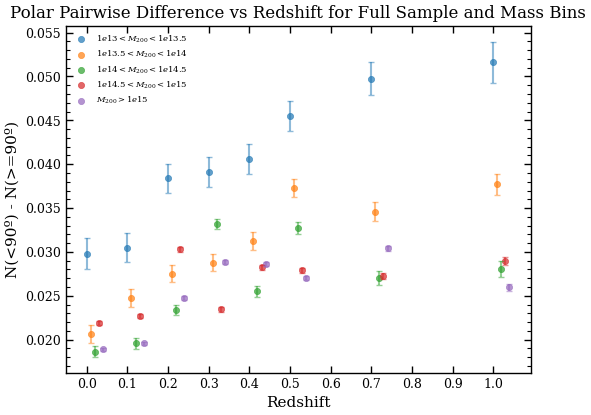

In [31]:

#in one    
polarPairwiseDifference_plotter, polarPairwiseDifference_fig, polarPairwiseDifference_ax, polar_pairwise_by_type_by_redshift = asymetryPlots(redshifts, listRedshiftGG=redshift_mass_bins, listGGLabels=mass_bin_labels, plotRows=1, plotCols=1)

polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/static_mass_polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')
    

Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...
Total Galaxy Groups to process: 2586 with pairs : 131308
Progress: Processing Galaxy Group ID 993, 2586 / 25866Total Galaxy Groups to process: 2317 with pairs : 140003
Progress: Processing Galaxy Group ID 1021, 2317 / 2317Total Galaxy Groups to process: 2105 with pairs : 142051
Progress: Processing Galaxy Group ID 2075, 2105 / 2105Total Galaxy Groups to process: 1933 with pairs : 136770
Progress: Processing Galaxy Group ID 2085, 1933 / 1933Total Galaxy Groups to process: 1729 with pairs : 134178
Progress: Processing Galaxy Group ID 2257, 1729 / 1729Total Galaxy Groups to process: 1531 with pairs : 125220
Progress: Processing Galaxy Group ID 2114, 1531 / 1531Total Galaxy Groups to process: 1155 with pairs : 105802
Progress: Processing Galaxy Group ID 2054, 1155 / 1155Total Galaxy Gr

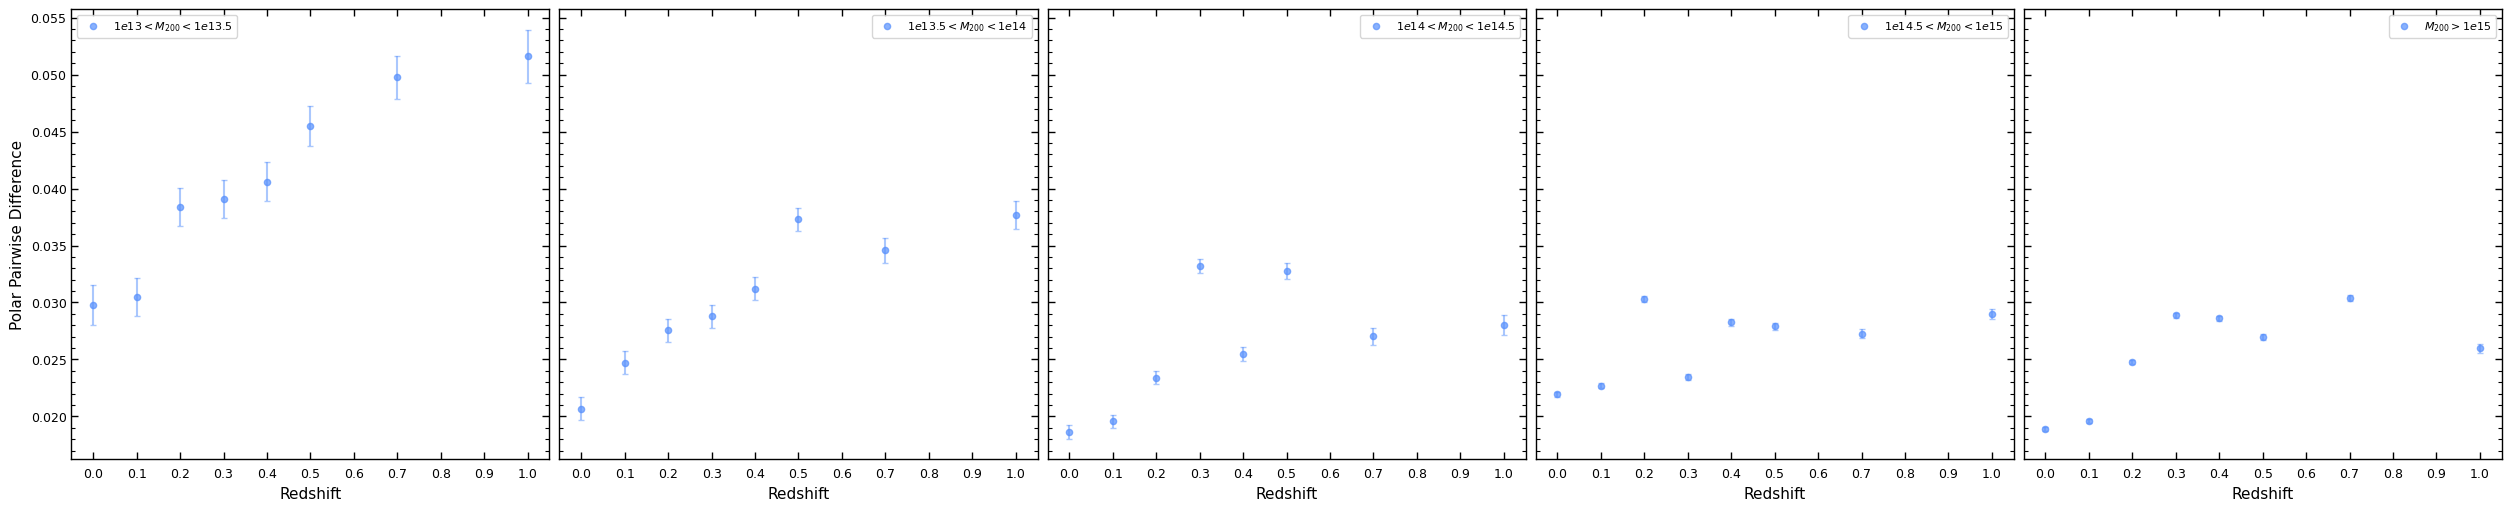

In [14]:
#separate assymetry plots for each mass bin:


assymetry_by_mass_plotter = AstroPlotter(style='cms', context='paper')
assymetry_by_mass_fig, assymetry_by_mass_ax = assymetry_by_mass_plotter.create_figure(nrows=1, ncols=len(mass_bin_labels), figsize=(5*len(mass_bin_labels), 5), sharey=True)

redshift_mass_bins : list[list[ListGalaxyGroup]]= []
redshifts = []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    redshift_mass_bins.append(mass_bins)
for i in range(len(mass_bin_labels)):
    mass_bin_color = mass_bin_colors[i % len(mass_bin_colors)]
    listRedshiftGG = []
    assymetry_by_mass_plotter, assymetry_by_mass_fig, assymetry_by_mass_ax[i], polar_pairwise_by_type_by_redshift = asymetryPlots(redshifts, listRedshiftGG=[[redshift_mass_bins[j][i]] for j in range(len(redshifts))], listGGLabels=[mass_bin_labels[i]], massColors = mass_bin_color, plotter=assymetry_by_mass_plotter, fig=assymetry_by_mass_fig, ax=assymetry_by_mass_ax[i])
    
    # assymetry_by_mass_ax[i].set_title(f'Polar Pairwise Difference vs Redshift for {mass_bin_labels[i]}')
    assymetry_by_mass_ax[i].label_outer()  # only show outer labels since we are sharing axes
assymetry_by_mass_ax[0].set_ylabel('Polar Pairwise Difference')
assymetry_by_mass_ax[-1].legend(fontsize=8, loc='upper right')
assymetry_by_mass_plotter.save_figure(assymetry_by_mass_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/static_polar_pairwise_difference_vs_redshift_separate_by_mass_bin_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')
plt.show()

Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...
Total Galaxy Groups to process: 2586 with pairs : 131308
Progress: Processing Galaxy Group ID 993, 2586 / 25866Total Galaxy Groups to process: 2317 with pairs : 140003
Progress: Processing Galaxy Group ID 1021, 2317 / 2317Total Galaxy Groups to process: 2105 with pairs : 142051
Progress: Processing Galaxy Group ID 2075, 2105 / 2105Total Galaxy Groups to process: 1933 with pairs : 136770
Progress: Processing Galaxy Group ID 2085, 1933 / 1933Total Galaxy Groups to process: 1729 with pairs : 134178
Progress: Processing Galaxy Group ID 2257, 1729 / 1729Total Galaxy Groups to process: 1531 with pairs : 125220
Progress: Processing Galaxy Group ID 2114, 1531 / 1531Total Galaxy Groups to process: 1155 with pairs : 105802
Progress: Processing Galaxy Group ID 2054, 1155 / 1155Total Galaxy Gr

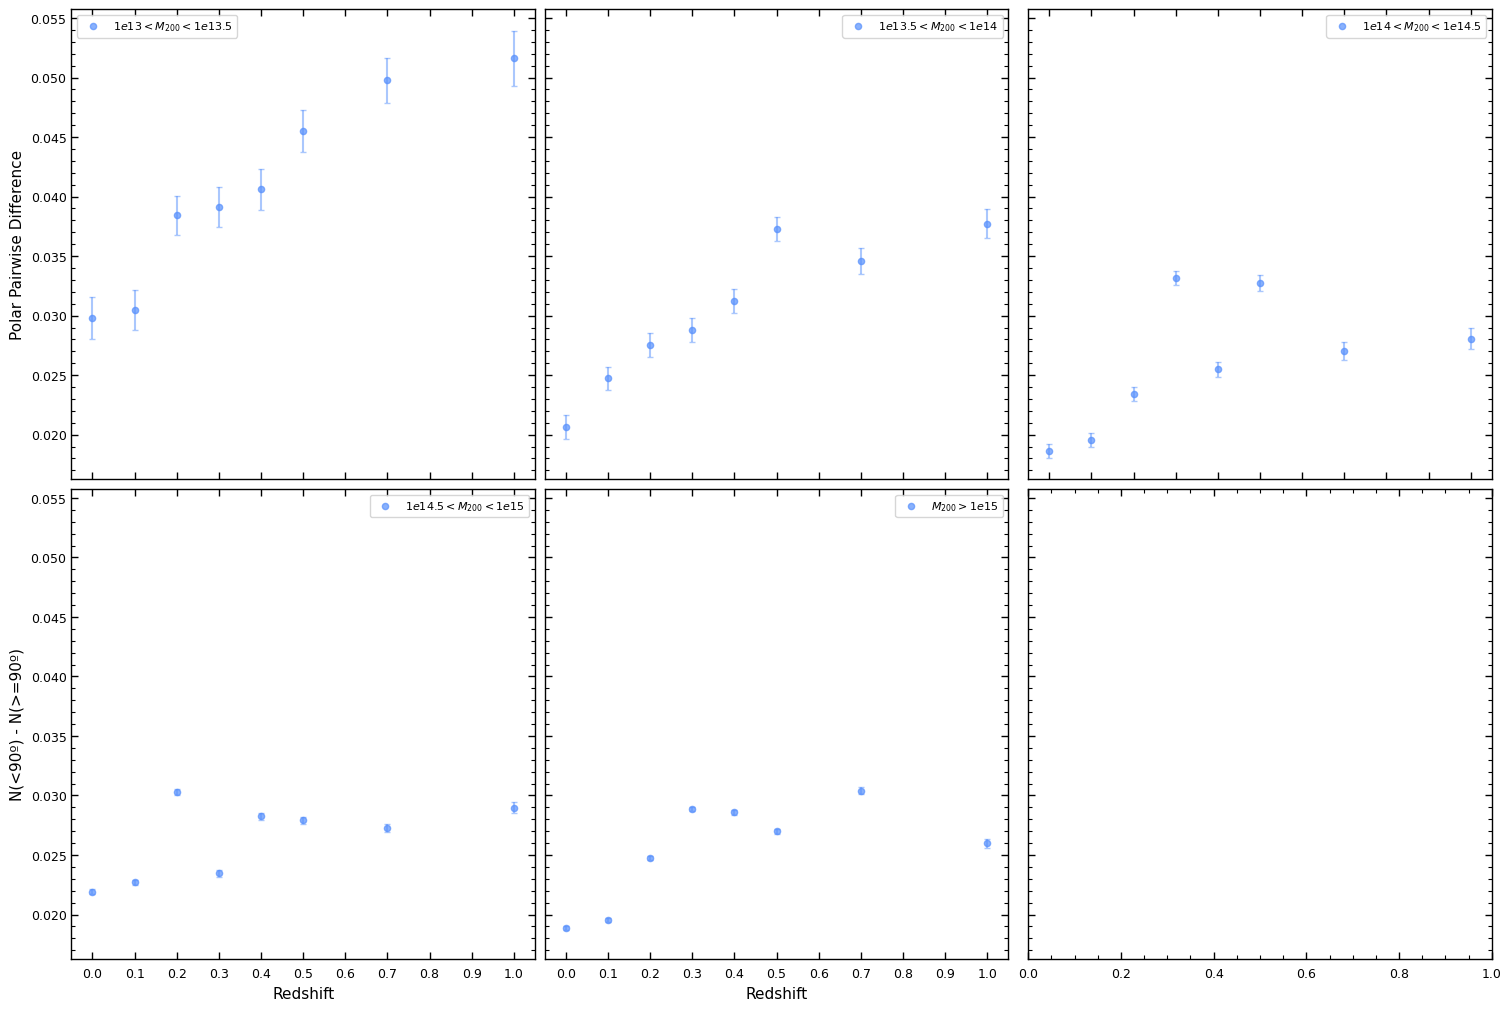

In [12]:
#separate assymetry plots for each mass bin:


assymetry_by_mass_plotter = AstroPlotter(style='cms', context='paper')
assymetry_by_mass_fig, assymetry_by_mass_ax = assymetry_by_mass_plotter.create_figure(nrows=2, ncols=3, figsize=(15, 10), sharey=True)

redshift_mass_bins : list[list[ListGalaxyGroup]]= []
redshifts = []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    redshift_mass_bins.append(mass_bins)
for i in range(len(mass_bin_labels)):
    mass_bin_color = mass_bin_colors[i % len(mass_bin_colors)]
    listRedshiftGG = []
    assymetry_by_mass_plotter, assymetry_by_mass_fig, assymetry_by_mass_ax[i//3, i%3], polar_pairwise_by_type_by_redshift = asymetryPlots(redshifts, listRedshiftGG=[[redshift_mass_bins[j][i]] for j in range(len(redshifts))], listGGLabels=[mass_bin_labels[i]], massColors = mass_bin_color, plotter=assymetry_by_mass_plotter, fig=assymetry_by_mass_fig, ax=assymetry_by_mass_ax[i//3, i%3])
    
    assymetry_by_mass_ax[i//3, i%3].label_outer()  # only show outer labels since we are sharing axes
assymetry_by_mass_ax[0, 0].set_ylabel('Polar Pairwise Difference')
assymetry_by_mass_ax[0, -1].legend(fontsize=8, loc='upper right')
assymetry_by_mass_plotter.save_figure(assymetry_by_mass_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_vs_redshift_separate_by_mass_bin_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')
plt.show()


## see what is causing assymetry plots

### general consistent vs inconsistent function

### general assymetry plot

processing snapshot: (99, 0, 'z0p0')
processing snapshot: (91, 0.1, 'z0p1')/ 632 with 428 satellites Galaxy Group 632 / 632 with 428 satellites
processing snapshot: (84, 0.2, 'z0p2')/ 602 with 322 satellites Galaxy Group 602 / 602 with 322 satellites
processing snapshot: (78, 0.3, 'z0p3')/ 577 with 374 satellites Galaxy Group 577 / 577 with 374 satellites
processing snapshot: (72, 0.4, 'z0p4')/ 549 with 136 satellites Galaxy Group 549 / 549 with 136 satellites
processing snapshot: (67, 0.5, 'z0p5')/ 529 with 226 satellites Galaxy Group 529 / 529 with 226 satellites
processing snapshot: (59, 0.7, 'z0p7')/ 493 with 201 satellites Galaxy Group 493 / 493 with 201 satellites
processing snapshot: (50, 1.0, 'z1p0')/ 432 with 264 satellites Galaxy Group 432 / 432 with 264 satellites
Total Galaxy Groups to process: 334 with pairs : 14800327llites Galaxy Group 312 / 312 with 191 satellites
Progress: Processing Galaxy Group ID 9956048, 334 / 3344Total Galaxy Groups to process: 298 with pairs : 50

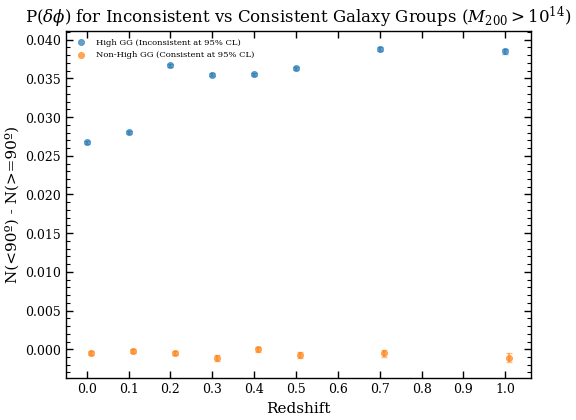

In [15]:
snapshotsAbove50 = [s for s in SnapshotEnum.getAllSnapshots() if s[0] >= 50]
consistent_inconsistent_assymetry_plotter, consistent_inconsistent_assymetry_fig, consistent_inconsistent_assymetry_ax, consistent_inconsistent_assymetry_by_type_by_redshift = getConsistentInconsistentAssymetryPlots(
    listRedshiftGalaxyAnalysis=listRedshiftGalaxyAnalysis,
    allSnapshotEnums=snapshotsAbove50,
    mass_bin_getter=lambda snapshot: snapshot.filtered_gt14_list_of_galaxy_groups,
    mass_bin_label='$M_{200}>10^{14}$',
    percentageMRL=95,
)

consistent_inconsistent_assymetry_plotter.save_figure(
    consistent_inconsistent_assymetry_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc    + f'/static_consistent_inconsistent_assymetry_plots_for_gt14_mass_bin_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

### snapshot 99

In [13]:
#get the subhalos which are inconsistent with random
galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(99)
random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=100000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles

(fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values, random_MRL_values=random_MRL_values, percentile=95)
percentageMRL=95
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
consistentColor = colors[0]
inconsistentColor = colors[1]
#gg_indices_inconsistent is a dict with key of the index of the galaxy group that has at least one projection MRL value below the 95th percentile of its random distribution, and value of a list of the projection angles (xy, yz, or xz) for which the MRL value is below the 95th percentile of its random distribution

In [13]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
import numpy as np
print(gg_indices_inconsistent)
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())
#see what are the properties of the gg which are inconsistent with random at 99 percentile, and see if they have any common properties among their subhalos which might be driving the lopsidedness in the polar pairwise distribution, and also see if they have any common properties among themselves (e.g. mass, redshift, number of subhalos, etc.)
high_galaxy_groups = []
non_high_galaxy_groups = []
for i, gg in enumerate(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()):
    if i not in gg_indices_inconsistent.keys():
        # print(f'Galaxy Group {i} is consistent with random at 95 percentile')
        non_high_galaxy_groups.append(gg)
        continue
    high_galaxy_groups.append(gg)
    
high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)

{0: ['xz'], 1: ['xy', 'yz', 'xz'], 2: ['xy', 'yz'], 3: ['yz', 'xz'], 4: ['yz'], 5: ['xy', 'yz'], 6: ['xy', 'xz'], 9: ['yz'], 12: ['xy', 'yz', 'xz'], 15: ['xy'], 17: ['xy', 'yz', 'xz'], 20: ['xy', 'yz'], 23: ['xy', 'yz'], 25: ['xy', 'yz'], 27: ['xy', 'yz'], 29: ['yz', 'xz'], 30: ['xy', 'yz', 'xz'], 39: ['yz'], 40: ['xy', 'yz', 'xz'], 42: ['yz'], 50: ['xz'], 52: ['xy', 'yz'], 54: ['xy', 'yz'], 58: ['yz', 'xz'], 62: ['xy', 'yz'], 64: ['xy', 'yz', 'xz'], 65: ['xy', 'xz'], 68: ['xy'], 69: ['xy', 'yz', 'xz'], 71: ['xz'], 72: ['xy'], 73: ['xy', 'xz'], 74: ['xy', 'yz'], 77: ['yz', 'xz'], 79: ['xy', 'yz', 'xz'], 83: ['xy', 'xz'], 85: ['xy', 'yz', 'xz'], 86: ['yz'], 87: ['yz', 'xz'], 92: ['xy', 'yz'], 98: ['xy', 'yz', 'xz'], 100: ['yz'], 101: ['xy', 'yz', 'xz'], 102: ['xy', 'yz', 'xz'], 103: ['xz'], 106: ['yz', 'xz'], 107: ['yz', 'xz'], 108: ['yz', 'xz'], 111: ['xy', 'yz'], 116: ['xy', 'xz'], 126: ['xy', 'xz'], 130: ['xy', 'yz', 'xz'], 132: ['xy', 'yz', 'xz'], 135: ['xy', 'yz', 'xz'], 136: ['xz'

In [14]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
consistentColor = colors[0]
inconsistentColor = colors[1]
numsamples=10000

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


((<Figure size 800x600 with 1 Axes>,
  <Axes: title={'center': 'Pairwise Polar Difference Distribution (TNG300-1, TNG-Cluster;\n280 groups; 95th-percentile MRL criterion)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>),
 (<Figure size 800x600 with 1 Axes>,
  <Axes: title={'center': 'MRL Value Distribution for TNG300-1, TNG-CLuster Combined\nGalaxy Groups, Consistent vs Inconsistent Projections'}, xlabel='MRL Value', ylabel='Probability Density'>),
 {0: ['xy', 'xz'],
  1: ['xy', 'yz', 'xz'],
  2: ['xy', 'yz'],
  3: ['yz', 'xz'],
  4: ['yz'],
  5: ['xy', 'yz'],
  6: ['xy', 'xz'],
  9: ['yz'],
  12: ['xy', 'yz', 'xz'],
  15: ['xy'],
  17: ['xy', 'yz', 'xz'],
  20: ['xy', 'yz'],
  23: ['xy', 'yz'],
  25: ['xy', 'yz'],
  27: ['xy', 'yz'],
  29: ['yz', 'xz'],
  30: ['xy', 'yz', 'xz'],
  39: ['yz'],
  40: ['xy', 'yz', 'xz'],
  42: ['yz'],
  50: ['xz'],
  52: ['xy', 'yz'],
  54: ['xy', 'yz'],
  58: ['yz', 'xz'],
  60: ['yz'],
  62: ['xy', 'yz'],
  64: ['xy', 'yz

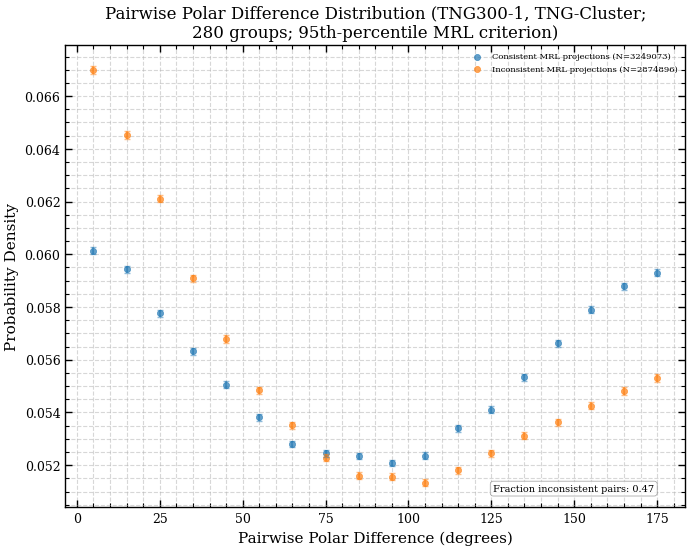

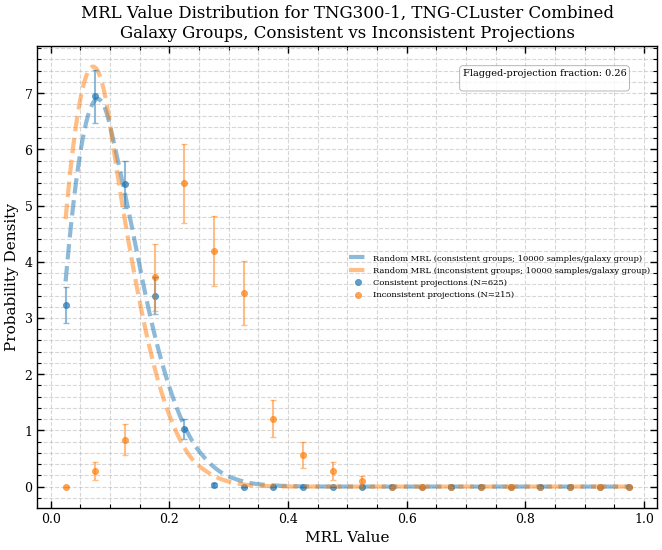

In [15]:
getConsistentInconsistentPolarMRLPlots(list_gg=galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, snapshot=99, percentConfidenceMRL=95)

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Do the same but for the MRL values instead of the polar pairwise differences, and see if the
# inconsistent projections have systematically different MRL values than the consistent projections.
#
# IMPORTANT:
# - gg_indices_inconsistent is keyed by index in the filtered_gt14 list.
# - Include all groups in the filtered_gt14 list (missing key => no inconsistent projections).
numsamples = 100000
percentageMRL = 95

if "MRL_values" not in globals() or "random_MRL_values" not in globals() or "gg_indices_inconsistent" not in globals():
    raise RuntimeError("Run Cell 46 first (needs MRL_values, random_MRL_values, gg_indices_inconsistent).")

# mrl_plotter = AstroPlotter()
# mrl_fig, mrl_ax = mrl_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))

consistent_MRL_values = []
inconsistent_MRL_values = []

# NOTE: GalaxyAnalysis.calculate_fraction_less_than_percentile assumes group ordering [xy, xz, yz].
proj_to_idx = {"xy": 0, "xz": 2, "yz": 1}
projections_all = ["xy", "xz", "yz"]

filtered_gt14 = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups

### MRL < 0.2

Galaxy Group 0 has inconsistent projection 'xz' with MRL value 0.079 < 0.2


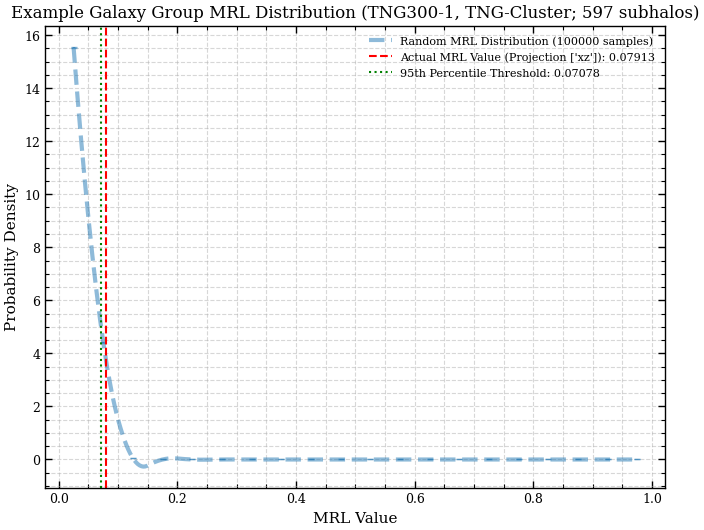

In [28]:
#grab the inconsistent galaxy groups with MRL below 0.2, choose say the first one and plot its sole random distribution with its singular actual MRL value
inconsistentGalaxyGroupsWithLowMRLToTest = []
inconsistentGalaxyGroupsWithLowMRLProjections = []
for group_index, galaxyGroup in enumerate(filtered_gt14.getAllGalaxyGroups()):
    inconsistentProjections = gg_indices_inconsistent.get(group_index, [])
    
    if len(inconsistentProjections) > 0:
        if inconsistentProjections == ["xy"] and MRL_values[group_index * 3 + proj_to_idx["xy"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xy' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xy']]:.3f} < 0.2")
            inconsistentGalaxyGroupsWithLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithLowMRLProjections.append(inconsistentProjections)
        elif inconsistentProjections == ["yz"] and MRL_values[group_index * 3 + proj_to_idx["yz"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'yz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['yz']]:.3f} < 0.2")
            inconsistentGalaxyGroupsWithLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithLowMRLProjections.append(inconsistentProjections)
        elif inconsistentProjections == ["xz"] and MRL_values[group_index * 3 + proj_to_idx["xz"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xz']]:.3f} < 0.2")
            inconsistentGalaxyGroupsWithLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithLowMRLProjections.append(inconsistentProjections)
            
        break  # stop after the first one for demonstration

if inconsistentGalaxyGroupsWithLowMRLToTest:
    example_group = inconsistentGalaxyGroupsWithLowMRLToTest[0]
    example_projections = inconsistentGalaxyGroupsWithLowMRLProjections[0]
    example_actual_MRL_values = ListGalaxyGroup._compute_MRL_for_group(example_group, projections=example_projections)
    example_random_MRL_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(
        num_samples=numsamples,
        num_non_centrals=len(example_group.getSatelliteSubhalos()),
    )

    example_plotter = AstroPlotter()
    example_fig, example_ax = example_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))
    bin = np.arange(0, 1.05, 0.05)
    xlabel = 'MRL Value'
    ylabel = 'Probability Density'
    title = f'Example Galaxy Group MRL Distribution (TNG300-1, TNG-Cluster; {len(example_group.getSatelliteSubhalos())} subhalos)'

    random_bins, random_bin_centers, random_errorbars = ListGalaxyGroup.get_histogram_bins(example_random_MRL_values, bins=bin, errorbarType='poisson', density=True)
    example_plotter.scatter_plot(
        random_bin_centers,
        random_bins,
        errorBars=random_errorbars,
        ax=example_ax,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        label=f"Random MRL Distribution ({numsamples} samples)",
        output_filename=None,
        alpha=0,
        grid=True,
        spline_curvature=True,
        spline_smoothing=0,
    )

    for idx, actual_mrl in enumerate(example_actual_MRL_values):
        if np.isfinite(actual_mrl):
            example_ax.axvline(actual_mrl, color='red', linestyle='--', label=f'Actual MRL Value (Projection {example_projections}): {actual_mrl:.5f}')
            #add text annotation for the actual MRL value
            # example_ax.text(
            #     actual_mrl,
            #     example_ax.get_ylim()[1] * 0.7,
            #     f'{actual_mrl:.3f}',
            #     color='red',
            #     fontsize=7,
            #     ha='center',
            #     va='top',
            #     rotation=90,
            #     backgroundcolor='white',
            # )
            
    #plot the 95th percentile threshold as well
    threshold_95 = np.percentile(example_random_MRL_values, percentageMRL)
    example_ax.axvline(threshold_95, color='green', linestyle=':', label=f'95th Percentile Threshold: {threshold_95:.5f}')
    #add text annotation for the threshold
    # example_ax.text(
    #     threshold_95,
    #     example_ax.get_ylim()[1] * 0.9,
    #     f'{threshold_95:.3f}',
    #     color='green',
    #     fontsize=7,
    #     ha='center',
    #     va='top',
    #     rotation=90,
    #     backgroundcolor='white',
    # )

    example_ax.set_xlabel(xlabel)
    example_ax.set_ylabel(ylabel)
    example_ax.set_title(title)
    example_ax.legend(fontsize=8)
else:
    print("No inconsistent galaxy groups with MRL below 0.2 found.")

### assymetry high vs low

Total Galaxy Groups to process: 330 with pairs : 14584056llites Galaxy Group 312 / 312 with 191 satellites
Progress: Processing Galaxy Group ID 9956048, 330 / 3300Total Galaxy Groups to process: 302 with pairs : 5216595
Progress: Processing Galaxy Group ID 9363765, 302 / 3022Total Galaxy Groups to process: 334 with pairs : 13006689
Progress: Processing Galaxy Group ID 9995792, 334 / 3344Total Galaxy Groups to process: 268 with pairs : 4562500
Progress: Processing Galaxy Group ID 10060723, 268 / 268Total Galaxy Groups to process: 318 with pairs : 11489696
Progress: Processing Galaxy Group ID 10050921, 318 / 318Total Galaxy Groups to process: 259 with pairs : 4252543
Progress: Processing Galaxy Group ID 10118255, 259 / 259Total Galaxy Groups to process: 317 with pairs : 11363051
Progress: Processing Galaxy Group ID 9951187, 317 / 3177Total Galaxy Groups to process: 232 with pairs : 3020354
Progress: Processing Galaxy Group ID 9736794, 232 / 2322Total Galaxy Groups to process: 318 with pa

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


[0.  0.1 0.2 0.3 0.4 0.5 0.7 1. ]
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_polar_pairwise_difference_vs_redshift_for_high_vs_nonhigh_galaxy_groups_TNG300-1, TNG-Cluster


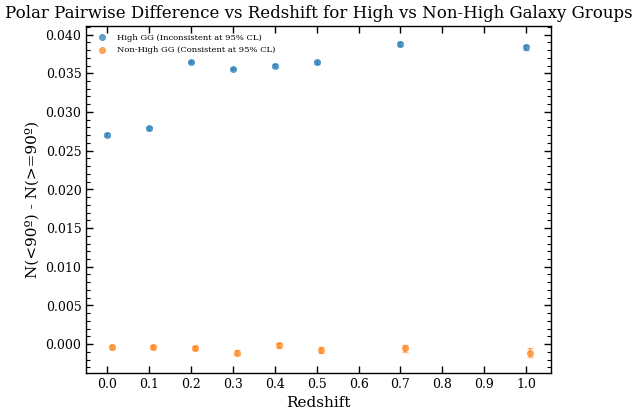

In [20]:
#make assymetry plots for the high galaxy groups and the non-high galaxy groups
# for snapshot_num in [50, 99]:
redshifts = []
redshift_mass_bins : list[list[ListGalaxyGroup]]= []

for snapshot_enum in allSnapshotEnums:
    snapshot_num = snapshot_enum[0]
    galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(snapshot_num)
    random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
    MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles

    (fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values, random_MRL_values=random_MRL_values, percentile=95)
    high_galaxy_groups = []
    non_high_galaxy_groups = []
    for i, gg in enumerate(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()):
        if i not in gg_indices_inconsistent:
            non_high_galaxy_groups.append(gg)
            continue
        high_galaxy_groups.append(gg)

    high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
    non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)
    
    redshifts.append(snapshot_enum[1])
    redshift_mass_bins.append([high_list_galaxy_groups, non_high_list_galaxy_groups])
polarPairwiseDifference_plotter, polarPairwiseDifference_fig, polarPairwiseDifference_ax, polar_pairwise_by_type_by_redshift = asymetryPlots(redshifts, listRedshiftGG=redshift_mass_bins, listGGLabels=['High GG (Inconsistent at 95% CL)', 'Non-High GG (Consistent at 95% CL)'], plotRows=1, plotCols=1)
polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for High vs Non-High Galaxy Groups')
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/static_polar_pairwise_difference_vs_redshift_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

### separate by mass high vs low

running over massbin i: 0xy Group 98 / 98 with 428 satellitesfor Galaxy Group 98 / 98 with 428 satellitesess
getting polarMRL plots now
running over massbin i: 1om MRL distribution, samples:10000, for Galaxy Group 2139 / 2139 with 13 satellites
getting polarMRL plots now
running over massbin i: 2om MRL distribution, samples:10000, for Galaxy Group 682 / 682 with 13 satellites
getting polarMRL plots now
running over massbin i: 3om MRL distribution, samples:10000, for Galaxy Group 184 / 184 with 60 satellitess
getting polarMRL plots now
running over massbin i: 4om MRL distribution, samples:10000, for Galaxy Group 94 / 94 with 328 satelliteses
getting polarMRL plots now


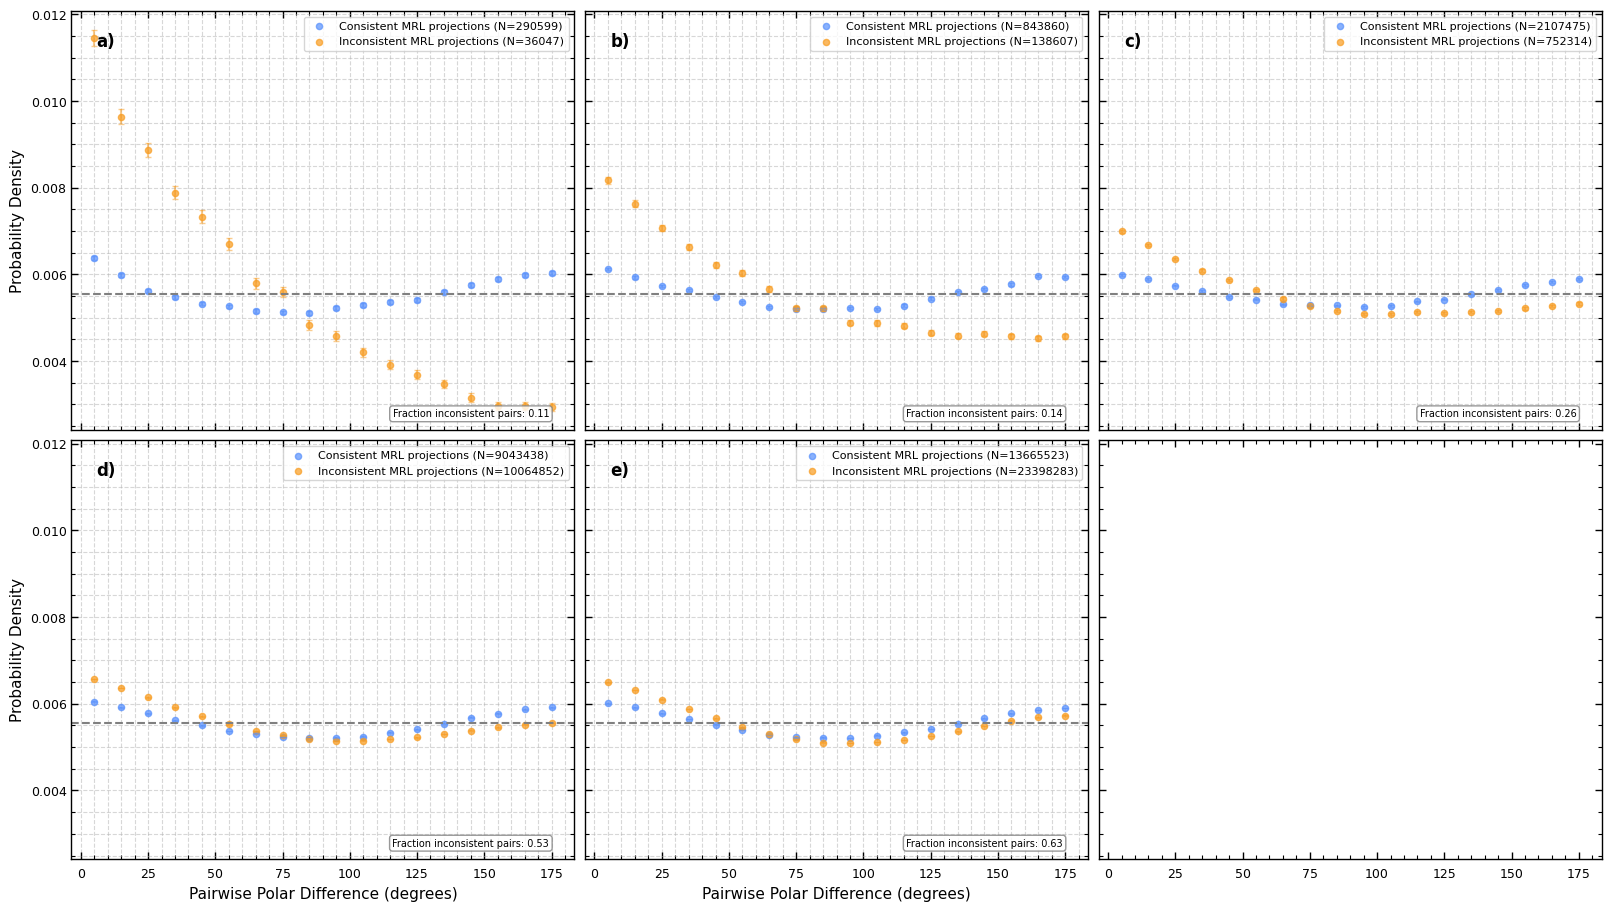

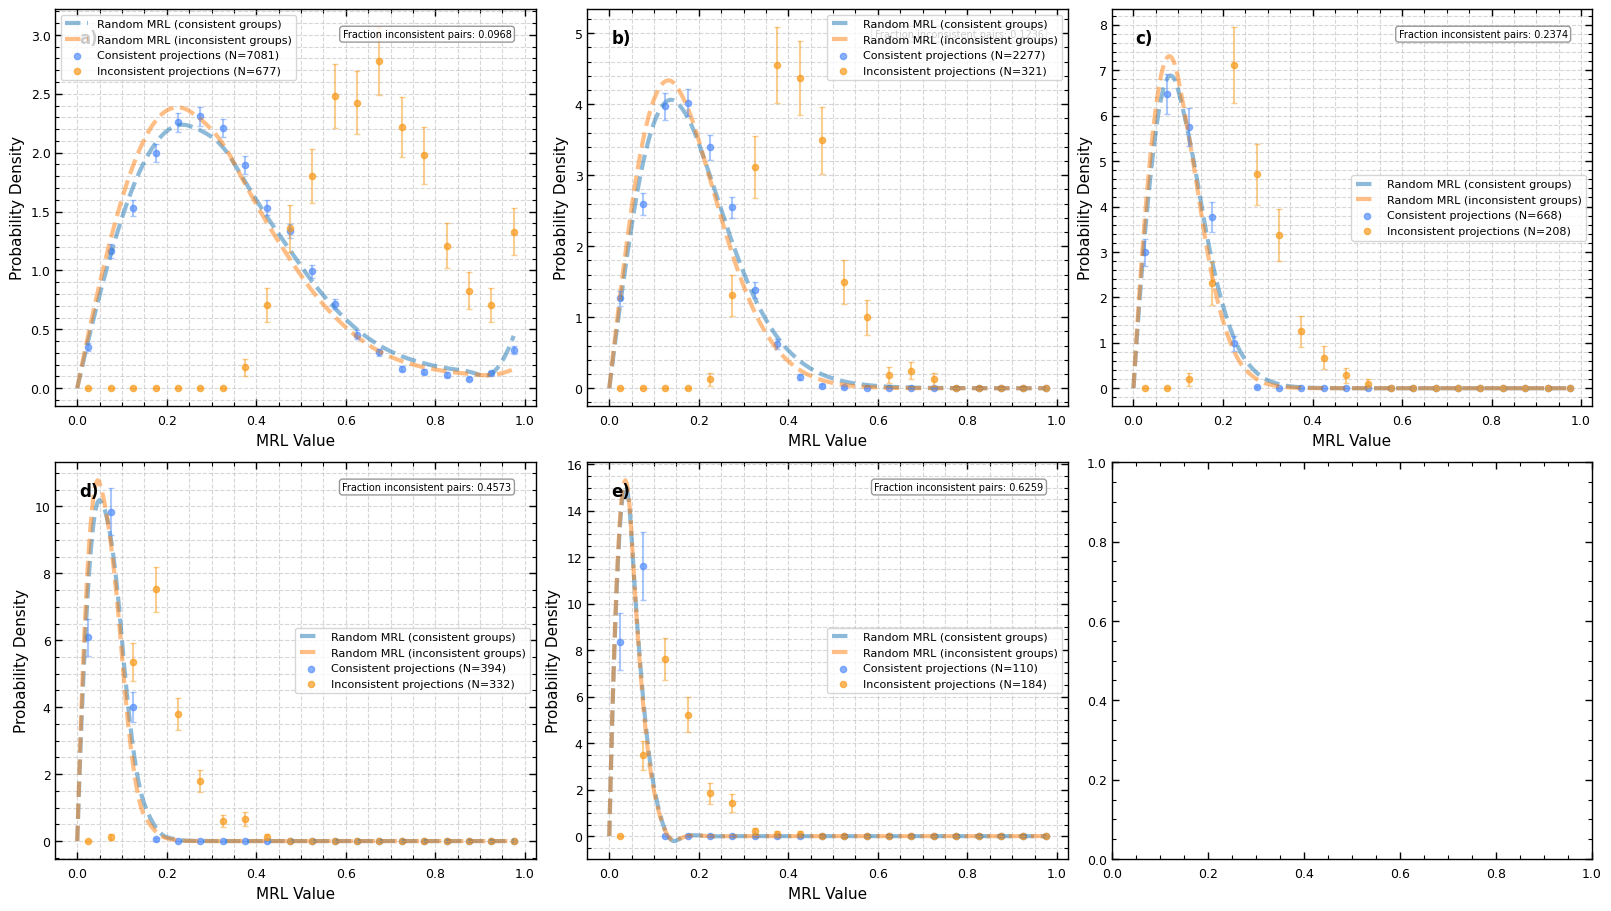

['/scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/combinedTNG300-1_TNGCluster/static_MRL_value_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_TNG300-1, TNG-Cluster.pdf',
 '/scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/combinedTNG300-1_TNGCluster/static_MRL_value_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_TNG300-1, TNG-Cluster.png']

In [17]:
#do but separate for each mass bin, and see if the high vs non-high difference is being driven by a particular mass bin
galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(99)
mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
random_MRL_values_by_mass_bin = []
MRL_values_by_mass_bin = []
for mass_bin in mass_bins:
    random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=10000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
    MRL_values = mass_bin.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles
    random_MRL_values_by_mass_bin.append(random_MRL_values)
    MRL_values_by_mass_bin.append(MRL_values)
    
inconsistent_galaxy_groups_by_mass_bin = []
consistent_galaxy_groups_by_mass_bin = []
#plot multipanel with getConsistentInconsistentPolarMRLPlots
plotter_polar_by_mass = AstroPlotter()
plotter_fig_polar_by_mass, axes_polar_by_mass = plotter_polar_by_mass.create_figure(ncols=3, nrows=2, figsize=(16, 9), sharex=True, sharey=True)
plotter_mrl_by_mass = AstroPlotter()
plotter_fig_mrl_by_mass, axes_mrl_by_mass = plotter_mrl_by_mass.create_figure(ncols=3, nrows=2, figsize=(16, 9), sharex=False, sharey=False)
    
for i, mass_bin in enumerate(mass_bins):
    print(f"running over massbin i: {i}")
    (fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values_by_mass_bin[i], random_MRL_values=random_MRL_values_by_mass_bin[i], percentile=95)
    high_galaxy_groups = []
    non_high_galaxy_groups = []
    for j, gg in enumerate(mass_bin.getAllGalaxyGroups()):
        if j not in gg_indices_inconsistent.keys():
            non_high_galaxy_groups.append(gg)
            continue
        high_galaxy_groups.append(gg)

    high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
    non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)
    
    inconsistent_galaxy_groups_by_mass_bin.append(high_list_galaxy_groups)
    consistent_galaxy_groups_by_mass_bin.append(non_high_list_galaxy_groups)
    
    print("getting polarMRL plots now")
    getConsistentInconsistentPolarMRLPlots(
        list_gg=mass_bin,
        snapshot=99,
        percentConfidenceMRL=95,
        gg_indices_inconsistent=gg_indices_inconsistent,
        mrl_values=MRL_values_by_mass_bin[i],
        numsamples_random_mrl=10000,
        polar_plotter=plotter_polar_by_mass,
        polar_ax=axes_polar_by_mass.flatten()[i],
        mrl_plotter=plotter_mrl_by_mass,
        mrl_ax=axes_mrl_by_mass.flatten()[i],
        random_MRL_values=random_MRL_values_by_mass_bin[i],
        # polar_title=f'Polar Pairwise Difference Distribution for {mass_bin_labels[i]}',
        # mrl_title=f'MRL Value Distribution for {mass_bin_labels[i]}',
    )

# add a), b), c) annotations to the polar plots
for i in range(len(mass_bins)):
    axes_polar_by_mass.flatten()[i].text(0.05, 0.95, f'{chr(97+i)})', transform=axes_polar_by_mass.flatten()[i].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    axes_polar_by_mass.flatten()[i].label_outer()  # only show outer labels since we are sharing axes
    axes_mrl_by_mass.flatten()[i].text(0.05, 0.95, f'{chr(97+i)})', transform=axes_mrl_by_mass.flatten()[i].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

plt.show()

plotter_polar_by_mass.save_figure(plotter_fig_polar_by_mass, galaxyAnalysisSnapshot.scratchPlotDirc + f'/static_polar_pairwise_difference_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')
plotter_mrl_by_mass.save_figure(plotter_fig_mrl_by_mass, galaxyAnalysisSnapshot.scratchPlotDirc + f'/static_MRL_value_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

processing snapshot: (99, 0, 'z0p0')5 / 675 with 15 satellitesr Galaxy Group 675 / 675 with 15 satelliteses


processing snapshot: (91, 0.1, 'z0p1') / 2586 with 13 satellites Galaxy Group 2586 / 2586 with 13 satellites
processing snapshot: (84, 0.2, 'z0p2') / 2317 with 11 satellites Galaxy Group 2317 / 2317 with 11 satellites
processing snapshot: (78, 0.3, 'z0p3') / 2105 with 10 satellites Galaxy Group 2105 / 2105 with 10 satellites
processing snapshot: (72, 0.4, 'z0p4') / 1933 with 10 satellites Galaxy Group 1933 / 1933 with 10 satellites
processing snapshot: (67, 0.5, 'z0p5') / 1729 with 16 satellites Galaxy Group 1729 / 1729 with 16 satellites
processing snapshot: (59, 0.7, 'z0p7') / 1531 with 16 satellites Galaxy Group 1531 / 1531 with 16 satellites
processing snapshot: (50, 1.0, 'z1p0') / 1155 with 15 satellites Galaxy Group 1155 / 1155 with 15 satellites
Total Galaxy Groups to process: 447 with pairs : 26735tellitesor Galaxy Group 675 / 675 with 15 satellites
Progress: Processing Galaxy Group ID 970, 447 / 4477Total Galaxy Groups to process: 2139 with pairs : 104573
Progress: Processing 

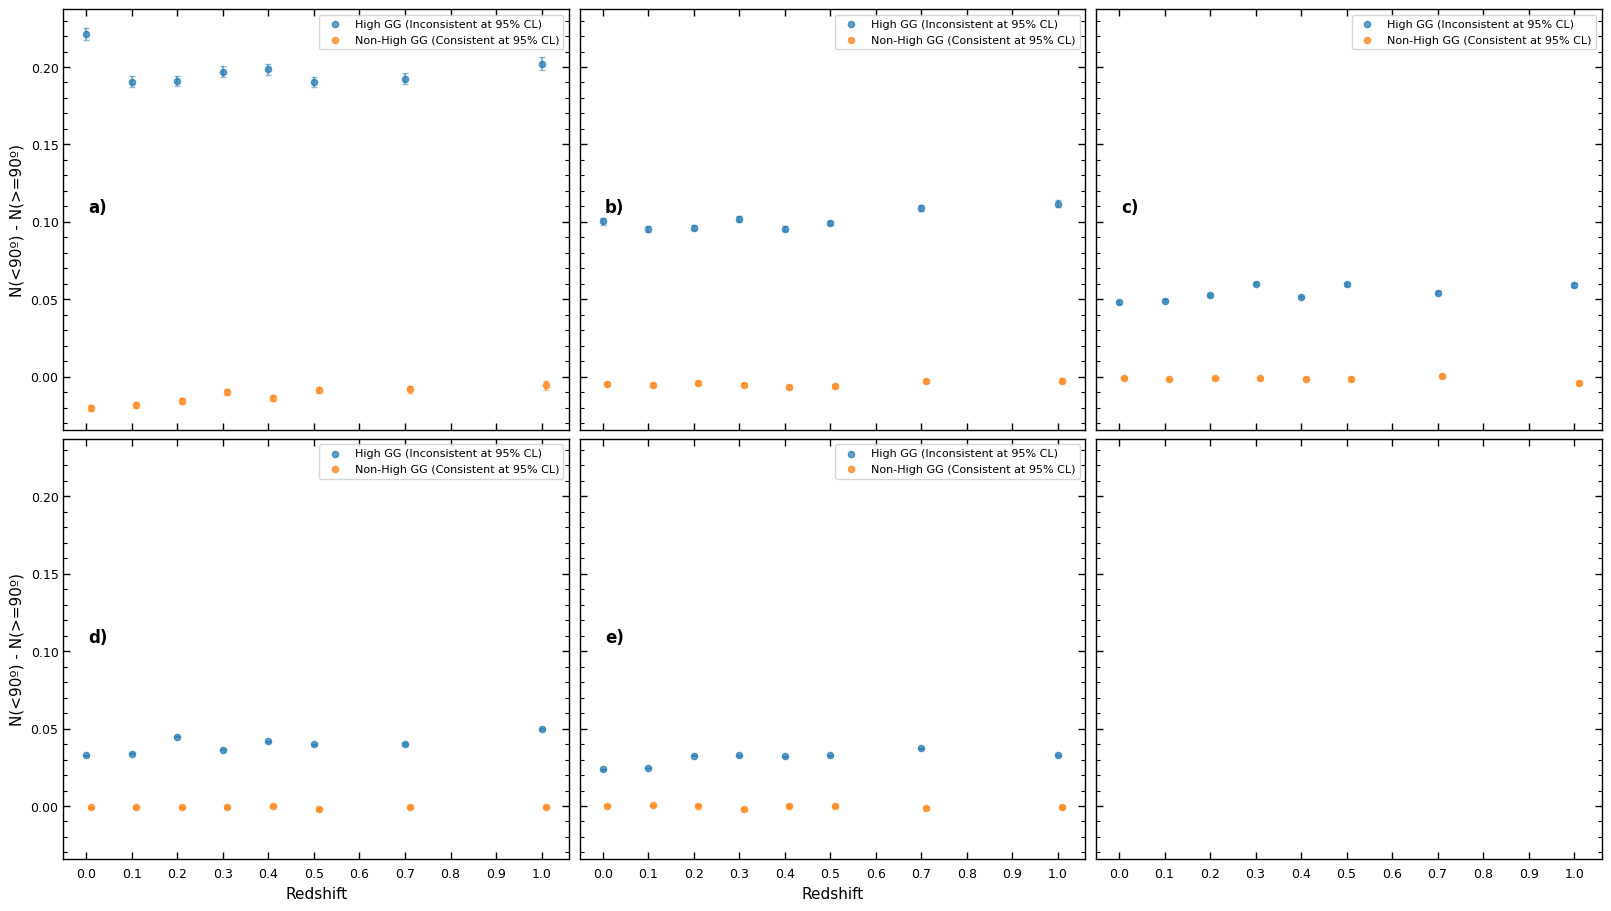

In [18]:
# Replicate Cell 55, but for each mass bin.
# For each snapshot and each mass bin:
#   1) compute MRL inconsistency indices
#   2) split into High vs Non-High
#   3) plot polar asymmetry (N(<90) - N(>=90)) vs redshift

mass_bin_labels = [
    "$1e13<M_{200}<1e13.5$",
    "$1e13.5<M_{200}<1e14$",
    "$1e14<M_{200}<1e14.5$",
    "$1e14.5<M_{200}<1e15$",
    "$M_{200}>1e15$",
]

mass_bin_getters = [
    lambda ga: ga.filtered_gt13_ls13p5_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt13p5_ls14_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt14_ls14p5_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt14p5_ls15_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt15_list_of_galaxy_groups,
]

plotter_polar_asymmetry_by_mass = AstroPlotter()
fig_polar_asymetry_by_mass, ax_polar_asymmetry_by_mass = plotter_polar_asymmetry_by_mass.create_figure(ncols=3, nrows=2, figsize=(16, 9), sharex=True, sharey=True)

for bin_i, (mass_label, get_mass_bin) in enumerate(zip(mass_bin_labels, mass_bin_getters)):
    redshifts = []
    redshift_gg_bins: list[list[ListGalaxyGroup]] = []

    for snapshot_enum in allSnapshotEnums:
        snapshot_num = snapshot_enum[0]
        galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(snapshot_num)

        mass_bin = get_mass_bin(galaxyAnalysisSnapshot)
        if mass_bin.getNumGalaxyGroups() == 0:
            continue

        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False,
            num_samples=1000,
        )
        MRL_values = mass_bin.compute_probablity_distribution_of_MRL_directionality(
            parallelize=False
        )

        (fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(
            MRL_values=MRL_values,
            random_MRL_values=random_MRL_values,
            percentile=95,
        )

        high_galaxy_groups = []
        non_high_galaxy_groups = []
        inconsistent_set = set(gg_indices_inconsistent)
        for i, gg in enumerate(mass_bin.getAllGalaxyGroups()):
            if i in inconsistent_set:
                high_galaxy_groups.append(gg)
            else:
                non_high_galaxy_groups.append(gg)

        high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
        non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)

        redshifts.append(snapshot_enum[1])
        redshift_gg_bins.append([high_list_galaxy_groups, non_high_list_galaxy_groups])

    if len(redshifts) == 0:
        print(f"Skipping {mass_label}: no groups across snapshots")
        continue

    #use getConsistentInconsistentAssymetryPlots
    getConsistentInconsistentAssymetryPlots(
        listRedshiftGalaxyAnalysis=listRedshiftGalaxyAnalysisCombined,
        allSnapshotEnums=allSnapshotEnums,
        mass_bin_getter=get_mass_bin,
        mass_bin_label=mass_label,
        percentageMRL=95,
        ax=ax_polar_asymmetry_by_mass.flatten()[bin_i],
        fig=fig_polar_asymetry_by_mass,
        plotter=plotter_polar_asymmetry_by_mass,
        # title=f"Polar Pairwise Difference Asymmetry vs Redshift for {mass_label}",
    )

#add a), b), c) annotations to the polar asymmetry plots
for i in range(len(mass_bin_labels)):
    ax_polar_asymmetry_by_mass.flatten()[i].text(0.05, 0.55, f'{chr(97+i)})', transform=ax_polar_asymmetry_by_mass.flatten()[i].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    ax_polar_asymmetry_by_mass.flatten()[i].label_outer()  # only show outer labels since we are sharing axes

plotter_polar_asymmetry_by_mass.save_figure(
    fig_polar_asymetry_by_mass,
    galaxyAnalysisSnapshot.scratchPlotDirc + f'/static_polar_pairwise_difference_asymmetry_vs_redshift_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}'
)
plt.show()

## median mass/members

In [ ]:
#see how median mass changes with redshift for the full sample and for the 5 mass bins (should be relatively flat since we are binning by mass, but good to check)
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
redshifts = []
median_mass_full_sample = []
median_mass_mass_bins = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])
    
    # Full sample median mass
    all_masses = []
    for mass_bin in mass_bins:
        for gg in mass_bin.getAllGalaxyGroups():
            all_masses.append(gg.getMCrit200())
    if len(all_masses) > 0:
        median_mass_full_sample.append(float(np.median(all_masses)))
    else:        
        median_mass_full_sample.append(np.nan)
    # Mass bin median masses
    for i, mass_bin in enumerate(mass_bins):
        masses = [gg.getMCrit200() for gg in mass_bin.getAllGalaxyGroups()]
        if len(masses) > 0:
            median_mass_mass_bins[i].append(float(np.median(masses)))
        else:
            median_mass_mass_bins[i].append(np.nan)
mass_bin_median_mass_plotter = AstroPlotter()
mass_bin_median_mass_fig, mass_bin_median_mass_ax = mass_bin_median_mass_plotter.create_figure()
# mass_bin_median_mass_ax.plot(
#     redshifts,
#     median_mass_full_sample,
#     label='Median Mass, Full Sample',
#     marker='o',
#     linestyle='-',
#     linewidth=1,
#     markersize=3,
# )
for i in range(len(mass_bin_labels)):
    mass_bin_median_mass_plotter.scatter_plot(
        redshifts,
        median_mass_mass_bins[i],
        label=f'{mass_bin_labels[i]}',
        marker='o',
        # linestyle='-',
        # linewidth=1,
        ax=mass_bin_median_mass_ax,
    )

mass_bin_median_mass_ax.set_xlabel('Redshift')
mass_bin_median_mass_ax.set_ylabel('Median M_200c [log M_sun]')
# mass_bin_median_mass_ax.set_title('Median Mass vs Redshift for Full Sample and Mass Bins')
mass_bin_median_mass_ax.legend(fontsize=8)
mass_bin_median_mass_ax.set_yscale('log')

#add additional yspace to the top of ylim to make space for the legend
ylim = mass_bin_median_mass_ax.get_ylim()
mass_bin_median_mass_ax.set_ylim(ylim[0], ylim[1] * 3)


mass_bin_median_mass_plotter.save_figure(
    mass_bin_median_mass_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/static_mass_median_mass_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

plt.show()

Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


['/scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_mass_median_mass_vs_redshift_for_full_sample_and_mass_bins_TNG300-1, TNG-Cluster.pdf',
 '/scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_mass_median_mass_vs_redshift_for_full_sample_and_mass_bins_TNG300-1, TNG-Cluster.png']

In [ ]:
# plot number of members in the clusters across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
redshifts = []
median_num_members_full_sample = []
median_num_members_mass_bins = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    print(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][0])
    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][0])
    
    # Full sample median number of members
    all_num_members = []
    for mass_bin in mass_bins:
        for gg in mass_bin.getAllGalaxyGroups():
            all_num_members.append(len(gg.getSatelliteSubhalos()))
    if len(all_num_members) > 0:
        median_num_members_full_sample.append(float(np.median(all_num_members)))
    else:
        median_num_members_full_sample.append(np.nan)
    
    # Mass bin median number of members
    for i, mass_bin in enumerate(mass_bins):
        num_members = [len(gg.getSatelliteSubhalos()) for gg in mass_bin.getAllGalaxyGroups()]
        if len(num_members) > 0:
            median_num_members_mass_bins[i].append(float(np.median(num_members)))
        else:
            median_num_members_mass_bins[i].append(np.nan)
            
mass_bin_median_num_members_plotter = AstroPlotter()
mass_bin_median_num_members_fig, mass_bin_median_num_members_ax = mass_bin_median_num_members_plotter.create_figure()
# mass_bin_median_num_members_ax.plot(
#     redshifts,
#     median_num_members_full_sample,
#     label='Median Number of Members, Full Sample',
#     marker='o',
#     linestyle='-',
#     linewidth=1,
#     markersize=3,
# )
for i in range(len(mass_bin_labels)):
    mass_bin_median_mass_plotter.scatter_plot(
        redshifts,
        median_num_members_mass_bins[i],
        label=f'{mass_bin_labels[i]}',
        marker='o',
        # linestyle='-',
        # linewidth=1,
        # markersize=3,
        ax=mass_bin_median_num_members_ax,
    )

mass_bin_median_num_members_ax.set_xlabel('Redshift')
mass_bin_median_num_members_ax.set_ylabel('Median Number of Members')
# mass_bin_median_num_members_ax.set_title('Median Number of Members vs Redshift for Full Sample and Mass Bins')
mass_bin_median_num_members_ax.legend(fontsize=8)
mass_bin_median_num_members_ax.set_yscale('log')

#add additional yspace to the top of ylim to make space for the legend
ylim = mass_bin_median_num_members_ax.get_ylim()
mass_bin_median_num_members_ax.set_ylim(ylim[0], ylim[1] * 3)

mass_bin_median_num_members_plotter.save_figure(
    mass_bin_median_num_members_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/static_mass_median_number_of_members_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

plt.show()

Processing snapshot 99...
0
Processing snapshot 91...
0.1
Processing snapshot 84...
0.2
Processing snapshot 78...
0.3
Processing snapshot 72...
0.4
Processing snapshot 67...
0.5
Processing snapshot 59...
0.7
Processing snapshot 50...
1.0


['/scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_mass_median_number_of_members_vs_redshift_for_full_sample_and_mass_bins_TNG300-1, TNG-Cluster.pdf',
 '/scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/static_mass_median_number_of_members_vs_redshift_for_full_sample_and_mass_bins_TNG300-1, TNG-Cluster.png']

In [17]:
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
gg0 = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getGalaxyGroupByID(0)
print(f"num members in galaxygroup 0 and snapshot 99: {len(gg0.getSatelliteSubhalos())}")

galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(50)
gg0 = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getGalaxyGroupByID(0)
print(f"num members in galaxygroup 0 and snapshot 50: {len(gg0.getSatelliteSubhalos())}")

num members in galaxygroup 0 and snapshot 99: 597
num members in galaxygroup 0 and snapshot 50: 377


## single polar piecewise plots

Processed group with M_200c = 1008248471683072.0 and 600 members
Processed group with M_200c = 1008924056616960.0 and 750 members
Fraction of MRL values below the 99th percentile of random MRL values: 0.0000 (0/3)2 with 751 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 0.6667 (2/3)2 with 751 satellites
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/combinedTNG300-1_TNGCluster/polar_difference_and_MRL_stats_for_1e15_mass_bin_snapshot_67_TNG300-1, TNG-Cluster


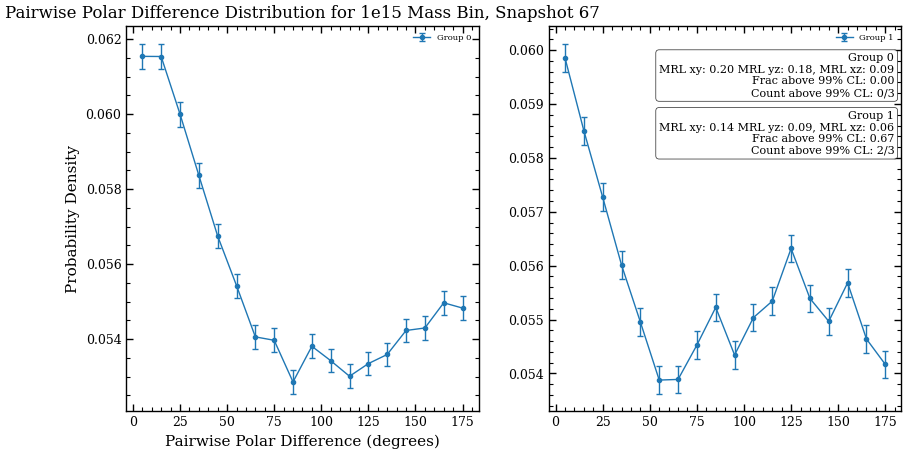

In [40]:
#make p(delta phi) plots for the 1e15 mass bin in snapshot 67
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(67)
mass_bin = galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups
list_mass_1e15_polar_differences = []
for gg in mass_bin.getAllGalaxyGroups():
    list_mass_1e15_polar_differences.append(ListGalaxyGroup._compute_pairwise_for_group(gg))
    print(f"Processed group with M_200c = {gg.getMCrit200()} and {len(gg.getSatelliteSubhalos())} members")
    
list_mass_1e15_counts, list_mass_1e15_bin_centers, list_mass_1e15_errorbars = [], [], []
for polar_differences in list_mass_1e15_polar_differences:
     counts, bin_edges, errorbars = ListGalaxyGroup.get_histogram_bins(polar_differences, bins=np.arange(0, 185, 10), errorbarType='poisson', normalize_to_one=True)
     list_mass_1e15_counts.append(counts)
     list_mass_1e15_bin_centers.append(bin_edges)
     list_mass_1e15_errorbars.append(errorbars)
     
polarDifference_1e15_plotter = AstroPlotter()
polarDifference_1e15_fig, polarDifference_1e15_ax = polarDifference_1e15_plotter.create_figure(ncols=2, nrows=1, figsize=(10, 5))
for i, polar_differences in enumerate(list_mass_1e15_polar_differences):
    polarDifference_1e15_ax[i].errorbar(
        list_mass_1e15_bin_centers[i],
        list_mass_1e15_counts[i],
        yerr=list_mass_1e15_errorbars[i],
        label=f'Group {i}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
polarDifference_1e15_ax[0].set_xlabel('Pairwise Polar Difference (degrees)')
polarDifference_1e15_ax[0].set_ylabel('Probability Density')
polarDifference_1e15_ax[0].set_title('Pairwise Polar Difference Distribution for 1e15 Mass Bin, Snapshot 67')
polarDifference_1e15_ax[0].legend(fontsize=6)

#include MRL value and MRL fraction above 99% random MRL CL for each group in the 1e15 mass bin in snapshot 67 as a text box
for i, gg in enumerate(mass_bin.getAllGalaxyGroups()):
    MRL_value = ListGalaxyGroup._compute_MRL_for_group(gg)
    random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=100000)
    (MRL_fraction_above_99_CL, counts_above_99_CL, total_count, subhaloIndexInconsistentWithRandom), MRL_values, random_MRL_values = GalaxyAnalysis.getPercentOfClustersAboveRandomMRLCL(MRL_values = MRL_value, percentageMRL=99, random_mrl_values=random_MRL_values)
    
    textstr = f'Group {i}\nMRL xy: {MRL_value[0]:.2f} MRL yz: {MRL_value[1]:.2f}, MRL xz: {MRL_value[2]:.2f}\nFrac above 99% CL: {MRL_fraction_above_99_CL:.2f}\nCount above 99% CL: {counts_above_99_CL}/{total_count}'
    # place all group boxes on the right side of the second subplot, stacked vertically, right-aligned
    polarDifference_1e15_ax[1].text(
        0.98,
        0.93 - i * 0.15,
        textstr,
        transform=polarDifference_1e15_ax[1].transAxes,
        fontsize=8,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    )
# polarDifference_1e15_ax[1].axis('off')
# polarDifference_1e15_ax[1].set_title('MRL and Fraction Above 99% CL for Each Group in 1e15 Mass Bin, Snapshot 67')
polarDifference_1e15_ax[1].legend(fontsize=6)
polarDifference_1e15_plotter.save_figure(
    polarDifference_1e15_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/static_mass_polar_difference_and_MRL_stats_for_1e15_mass_bin_snapshot_67_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processed group with M_200c = 494967835328512.0 and 632 members
Processed group with M_200c = 468957177839616.0 and 555 members
Processed group with M_200c = 319796923072512.0 and 448 members
Processed group with M_200c = 331614995349504.0 and 361 members
Fraction of MRL values below the 99th percentile of random MRL values: 0.3333 (1/3)4 with 362 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 0.3333 (1/3)4 with 362 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 0.3333 (1/3)4 with 362 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 1.0000 (3/3)4 with 362 satellites
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_difference_and_MRL_stats_for_1e14.5-1e15_mass_bin_snapshot_50_TNG300-1, TNG-Cluster


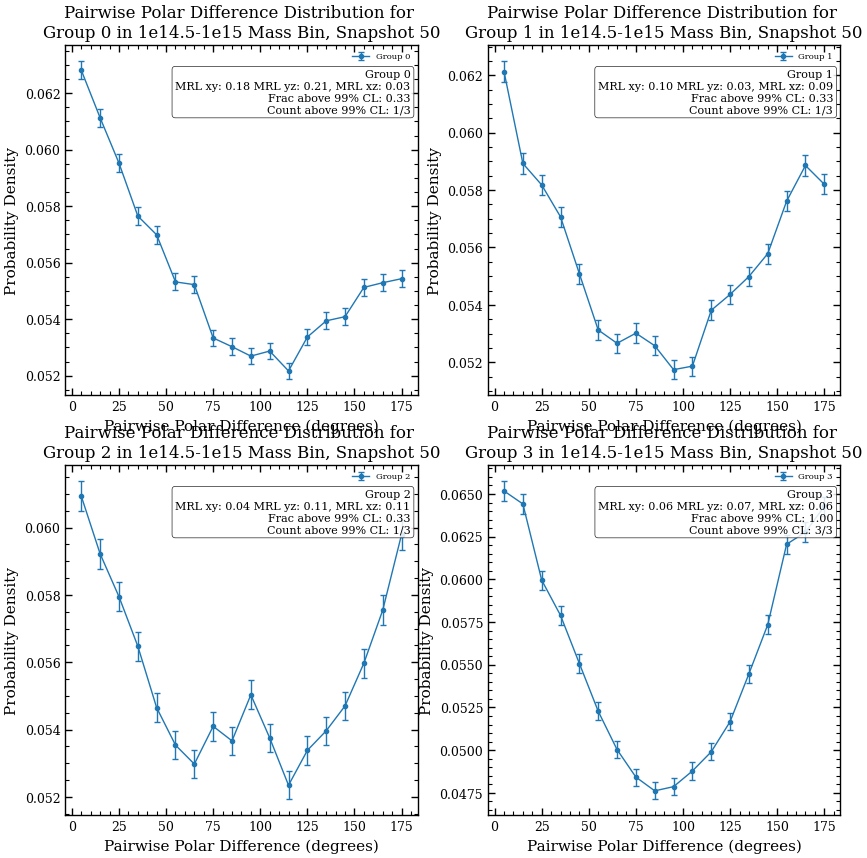

In [48]:
#do the same for the 4 1e14.5-1e15 at snapshot 50
galaxyAnalysisSnapshot = getListRedshiftGalaxyAnalysisForSnap(50)
mass_bin = galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups
list_mass_14p5_15_polar_differences = []
for gg in mass_bin.getAllGalaxyGroups():
    list_mass_14p5_15_polar_differences.append(ListGalaxyGroup._compute_pairwise_for_group(gg))
    print(f"Processed group with M_200c = {gg.getMCrit200()} and {len(gg.getSatelliteSubhalos())} members")
list_mass_14p5_15_counts, list_mass_14p5_15_bin_centers, list_mass_14p5_15_errorbars = [], [], []
for polar_differences in list_mass_14p5_15_polar_differences:
     counts, bin_edges, errorbars = ListGalaxyGroup.get_histogram_bins(polar_differences, bins=np.arange(0, 185, 10), errorbarType='poisson', normalize_to_one=True)
     list_mass_14p5_15_counts.append(counts)
     list_mass_14p5_15_bin_centers.append(bin_edges)
     list_mass_14p5_15_errorbars.append(errorbars)
polarDifference_14p5_15_plotter = AstroPlotter()
polarDifference_14p5_15_fig, polarDifference_14p5_15_ax = polarDifference_14p5_15_plotter.create_figure(ncols=2, nrows=2, figsize=(10, 10))
for i, polar_differences in enumerate(list_mass_14p5_15_polar_differences):
    polarDifference_14p5_15_ax[i//2, i%2].errorbar(
        list_mass_14p5_15_bin_centers[i],
        list_mass_14p5_15_counts[i],
        yerr=list_mass_14p5_15_errorbars[i],
        label=f'Group {i}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
    MRL_value = ListGalaxyGroup._compute_MRL_for_group(mass_bin.getAllGalaxyGroups()[i])
    random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=100000)
    (MRL_fraction_above_99_CL, counts_above_99_CL, total_count, subhaloIndexInconsistentWithRandom), MRL_values, random_MRL_values = GalaxyAnalysis.getPercentOfClustersAboveRandomMRLCL(MRL_values = MRL_value, percentageMRL=99, random_mrl_values=random_MRL_values)
    
    textstr = f'Group {i}\nMRL xy: {MRL_value[0]:.2f} MRL yz: {MRL_value[1]:.2f}, MRL xz: {MRL_value[2]:.2f}\nFrac above 99% CL: {MRL_fraction_above_99_CL:.2f}\nCount above 99% CL: {counts_above_99_CL}/{total_count}'
    # place all group boxes on the right side of the second subplot, stacked vertically, right-aligned
    polarDifference_14p5_15_ax[i//2, i%2].text(
        0.98,
        0.93,
        textstr,
        transform=polarDifference_14p5_15_ax[i//2, i%2].transAxes,
        fontsize=8,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    )
    polarDifference_14p5_15_ax[i//2, i%2].set_xlabel('Pairwise Polar Difference (degrees)')
    polarDifference_14p5_15_ax[i//2, i%2].set_ylabel('Probability Density')
    polarDifference_14p5_15_ax[i//2, i%2].set_title(f'Pairwise Polar Difference Distribution for \nGroup {i} in 1e14.5-1e15 Mass Bin, Snapshot 50')
    polarDifference_14p5_15_ax[i//2, i%2].legend(fontsize=6)
polarDifference_14p5_15_plotter.save_figure(
    polarDifference_14p5_15_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/static_mass_polar_difference_and_MRL_stats_for_1e14.5-1e15_mass_bin_snapshot_50_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)